<a href="https://colab.research.google.com/github/memory-Alice/quant-system-ovo/blob/main/quant_system_v0_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quant System V0.1

A research-oriented multi-factor equity selection and backtesting system.

## Strategy

The system ranks stocks using two factors:

- 120-Day Momentum — 70%
- Earnings Growth — 30%

The portfolio selects the Top 2 stocks each month and allocates 50% to each.

## Universe

- MU
- NVDA
- TSLA
- LLY

## Research Pipeline

Market Data
→ Factor Construction
→ IC Testing
→ Train/Test Validation
→ Multi-Factor Scoring
→ Portfolio Construction
→ Backtesting
→ Benchmark Comparison

## Evaluation Period

2016–2022: Factor research / training period

2023–2026: Out-of-sample-style evaluation period

## Key Result

During the 2023–2026 evaluation period:

- Multi-Factor CAGR: 83.70%
- Multi-Factor Sharpe: 1.62
- Multi-Factor Maximum Drawdown: -40.19%

Equal-Weight Benchmark:

- CAGR: 87.10%
- Sharpe: 1.99
- Maximum Drawdown: -31.66%

The V0.1 strategy did not outperform the equal-weight benchmark during the evaluation period.

## Limitations

- Small stock universe
- Selection / survivorship bias
- Earnings Growth data availability differs across companies
- Evaluation period has already been inspected during research
- Transaction-cost model is simplified

## Next Version

V0.2 will explore:

- Larger stock universe
- Additional factors
- Machine-learning models
- Stronger out-of-sample validation
- Paper trading / forward testing

In [ ]:
# Step 1: 安装并导入量化需要的基础工具
!pip -q install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Quant environment ready!")

Quant environment ready!


In [ ]:
# Step 2: 下载 MU 最近两年的股票数据

ticker = "MU"

data = yf.download(
    ticker,
    period="2y",
    auto_adjust=True,
    progress=False
)

print("Rows:", len(data))
data.tail(10)

Rows: 501


Price,Close,High,Low,Open,Volume
Ticker,MU,MU,MU,MU,MU
Date,,,,,
2026-09-14,924.030029,932.210022,902.599976,906.030029,27141900
2026-09-15,927.599976,944.940002,920.130005,937.500000,20434700
2026-09-16,926.549988,941.200012,917.640015,934.229980,20213000
2026-09-17,977.500000,986.200012,953.500000,954.570007,22091600
2026-09-18,1015.799988,1016.440002,977.830017,984.719971,35803500
2026-09-21,1043.959961,1064.489990,1030.680054,1044.989990,28174400
2026-09-22,1096.160034,1097.250000,1030.020020,1032.849976,29189700
2026-09-23,1071.880005,1105.500000,1064.250000,1100.069946,21572800


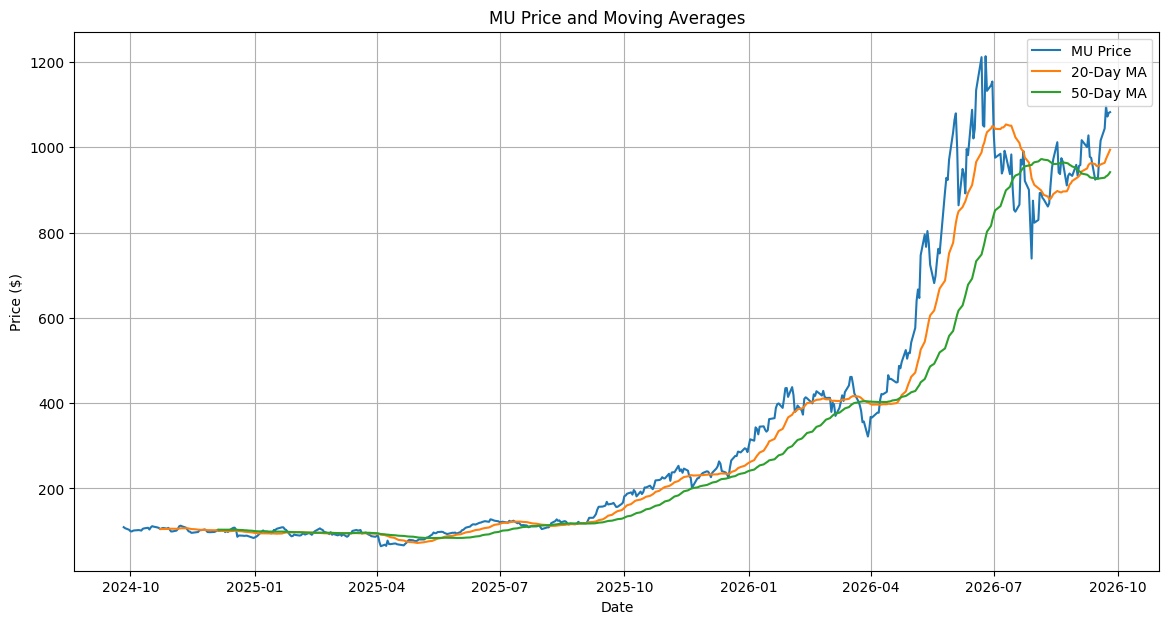

In [ ]:
# Step 3: 计算 20 日和 50 日均线

close = data["Close"]["MU"]

data["MA20"] = close.rolling(20).mean()
data["MA50"] = close.rolling(50).mean()

plt.figure(figsize=(14, 7))

plt.plot(data.index, close, label="MU Price")
plt.plot(data.index, data["MA20"], label="20-Day MA")
plt.plot(data.index, data["MA50"], label="50-Day MA")

plt.title("MU Price and Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Step 4: 产生买卖信号

signal = (data["MA20"] > data["MA50"]).astype(int)

buy = (signal == 1) & (signal.shift(1) == 0)
sell = (signal == 0) & (signal.shift(1) == 1)

print("BUY dates:")
print(data.index[buy])

print("\nSELL dates:")
print(data.index[sell])

BUY dates:
DatetimeIndex(['2025-01-31', '2025-03-04', '2025-05-20', '2025-08-29',
               '2026-04-24', '2026-09-04'],
              dtype='datetime64[ns]', name='Date', freq=None)

SELL dates:
DatetimeIndex(['2025-02-13', '2025-03-11', '2025-08-06', '2026-03-30',
               '2026-07-28'],
              dtype='datetime64[ns]', name='Date', freq=None)


In [ ]:
# Step 5: 回测均线策略

returns = close.pct_change()

# 信号延迟一天，避免使用当天收盘价提前交易
position = signal.shift(1).fillna(0)

strategy_returns = returns * position

initial_money = 10000

strategy_value = initial_money * (1 + strategy_returns).cumprod()
buy_hold_value = initial_money * (1 + returns).cumprod()

print("Initial money: $10,000")
print(f"Strategy final value: ${strategy_value.iloc[-1]:,.2f}")
print(f"Buy & Hold final value: ${buy_hold_value.iloc[-1]:,.2f}")

print(f"Strategy return: {(strategy_value.iloc[-1]/initial_money-1)*100:.2f}%")
print(f"Buy & Hold return: {(buy_hold_value.iloc[-1]/initial_money-1)*100:.2f}%")

Initial money: $10,000
Strategy final value: $54,118.85
Buy & Hold final value: $99,116.00
Strategy return: 441.19%
Buy & Hold return: 891.16%


In [ ]:
# Step 6: 检查 MU 数据是否正常

print("First date:", data.index[0])
print("Last date:", data.index[-1])

print("\nFirst 5 closing prices:")
print(close.head())

print("\nLast 5 closing prices:")
print(close.tail())

print("\nMinimum price:", close.min())
print("Maximum price:", close.max())

First date: 2024-09-26 00:00:00
Last date: 2026-09-25 00:00:00

First 5 closing prices:
Date
2024-09-26    109.193275
2024-09-27    106.828133
2024-09-30    103.061829
2024-10-01     99.683083
2024-10-02     99.225960
Name: MU, dtype: float64

Last 5 closing prices:
Date
2026-09-21    1043.959961
2026-09-22    1096.160034
2026-09-23    1071.880005
2026-09-24    1080.530029
2026-09-25    1082.280029
Name: MU, dtype: float64

Minimum price: 64.55552673339844
Maximum price: 1213.3734130859375


In [ ]:
# Step 7: 计算最大回撤 Maximum Drawdown

def max_drawdown(portfolio):
    peak = portfolio.cummax()
    drawdown = (portfolio - peak) / peak
    return drawdown.min()

strategy_mdd = max_drawdown(strategy_value)
buy_hold_mdd = max_drawdown(buy_hold_value)

print(f"Strategy Maximum Drawdown: {strategy_mdd:.2%}")
print(f"Buy & Hold Maximum Drawdown: {buy_hold_mdd:.2%}")

Strategy Maximum Drawdown: -38.53%
Buy & Hold Maximum Drawdown: -42.78%


In [ ]:
# Step 8: 年化收益率、波动率和 Sharpe Ratio

# 去掉空值
strategy_daily = strategy_returns.fillna(0)
buy_hold_daily = returns.fillna(0)

# 年化收益率（CAGR）
years = (data.index[-1] - data.index[0]).days / 365.25

strategy_cagr = (strategy_value.iloc[-1] / initial_money) ** (1 / years) - 1
buy_hold_cagr = (buy_hold_value.iloc[-1] / initial_money) ** (1 / years) - 1

# 年化波动率
strategy_vol = strategy_daily.std() * np.sqrt(252)
buy_hold_vol = buy_hold_daily.std() * np.sqrt(252)

# Sharpe Ratio
# 这里先假设无风险利率 = 0，方便学习
strategy_sharpe = strategy_daily.mean() / strategy_daily.std() * np.sqrt(252)
buy_hold_sharpe = buy_hold_daily.mean() / buy_hold_daily.std() * np.sqrt(252)

print("=== 20/50 MA Strategy ===")
print(f"Annual Return: {strategy_cagr:.2%}")
print(f"Annual Volatility: {strategy_vol:.2%}")
print(f"Sharpe Ratio: {strategy_sharpe:.2f}")

print("\n=== Buy & Hold Benchmark ===")
print(f"Annual Return: {buy_hold_cagr:.2%}")
print(f"Annual Volatility: {buy_hold_vol:.2%}")
print(f"Sharpe Ratio: {buy_hold_sharpe:.2f}")

=== 20/50 MA Strategy ===
Annual Return: 133.04%
Annual Volatility: 56.13%
Sharpe Ratio: 1.79

=== Buy & Hold Benchmark ===
Annual Return: 215.57%
Annual Volatility: 71.51%
Sharpe Ratio: 1.97


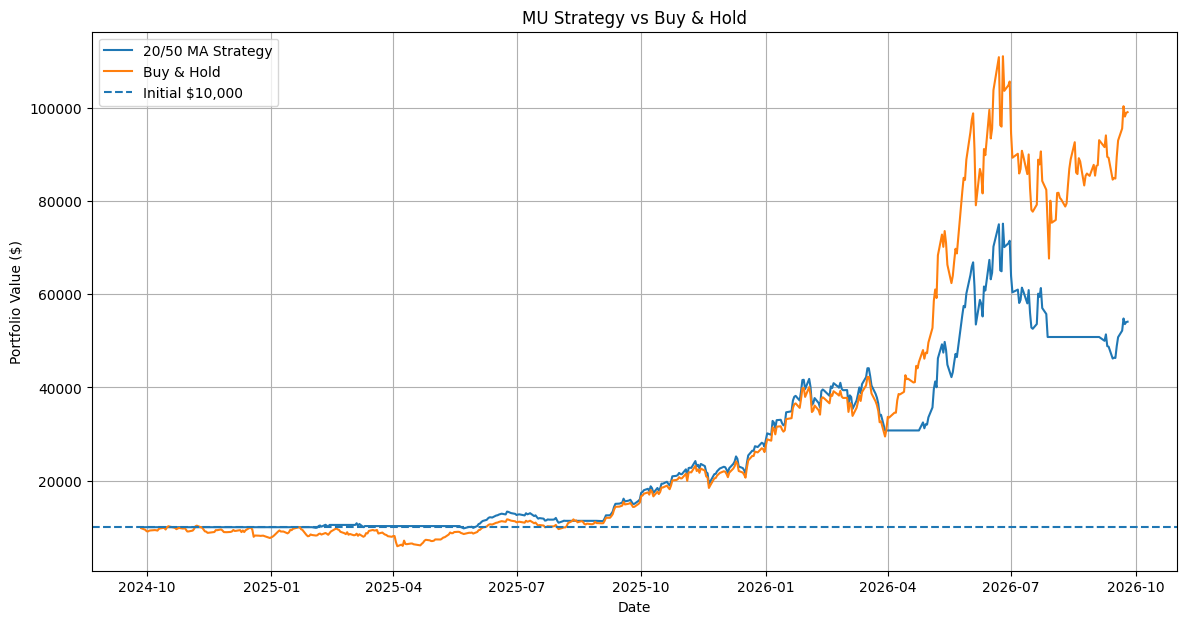

In [ ]:
# Step 9: 绘制资金曲线 Equity Curve

plt.figure(figsize=(14, 7))

plt.plot(
    strategy_value.index,
    strategy_value,
    label="20/50 MA Strategy"
)

plt.plot(
    buy_hold_value.index,
    buy_hold_value,
    label="Buy & Hold"
)

plt.axhline(
    y=initial_money,
    linestyle="--",
    label="Initial $10,000"
)

plt.title("MU Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Step 10: 生成每笔交易记录

trades = []
entry_date = None
entry_price = None

for i in range(1, len(data)):

    # BUY
    if buy.iloc[i]:
        entry_date = data.index[i]
        entry_price = close.iloc[i]

    # SELL
    elif sell.iloc[i] and entry_date is not None:
        exit_date = data.index[i]
        exit_price = close.iloc[i]

        trade_return = (exit_price / entry_price - 1) * 100

        trades.append({
            "Buy Date": entry_date,
            "Buy Price": entry_price,
            "Sell Date": exit_date,
            "Sell Price": exit_price,
            "Return (%)": trade_return
        })

        entry_date = None
        entry_price = None

trades_df = pd.DataFrame(trades)

print(trades_df)

if len(trades_df) > 0:
    win_rate = (trades_df["Return (%)"] > 0).mean() * 100
    print(f"\nNumber of completed trades: {len(trades_df)}")
    print(f"Win Rate: {win_rate:.2f}%")

    Buy Date   Buy Price  Sell Date  Sell Price  Return (%)
0 2025-01-31   90.889786 2025-02-13   95.292816    4.844362
1 2025-03-04   90.849945 2025-03-11   88.708199   -2.357455
2 2025-05-20   97.850693 2025-08-06  108.605690   10.991233
3 2025-08-29  118.819290 2026-03-30  321.750488  170.789775
4 2026-04-24  496.643616 2026-07-28  820.530029   65.215056

Number of completed trades: 5
Win Rate: 80.00%


In [ ]:
# Step 11: 统一交易执行逻辑
# 信号在当天收盘后产生，下一交易日执行

execution_buy = buy.shift(1, fill_value=False)
execution_sell = sell.shift(1, fill_value=False)

trades = []
entry_date = None
entry_price = None

for i in range(len(data)):

    # 下一交易日执行 BUY
    if execution_buy.iloc[i] and entry_date is None:
        entry_date = data.index[i]
        entry_price = close.iloc[i]

    # 下一交易日执行 SELL
    elif execution_sell.iloc[i] and entry_date is not None:
        exit_date = data.index[i]
        exit_price = close.iloc[i]

        trade_return = (exit_price / entry_price - 1) * 100

        trades.append({
            "Buy Date": entry_date,
            "Buy Price": entry_price,
            "Sell Date": exit_date,
            "Sell Price": exit_price,
            "Return (%)": trade_return
        })

        entry_date = None
        entry_price = None

trades_df = pd.DataFrame(trades)

print(trades_df)

print("\nNumber of completed trades:", len(trades_df))

if len(trades_df) > 0:
    win_rate = (trades_df["Return (%)"] > 0).mean() * 100
    print(f"Win Rate: {win_rate:.2f}%")

# 检查最后是否还有未平仓交易
if entry_date is not None:
    current_return = (close.iloc[-1] / entry_price - 1) * 100

    print("\nOPEN POSITION:")
    print("Buy Date:", entry_date)
    print(f"Buy Price: ${entry_price:.2f}")
    print(f"Latest Price: ${close.iloc[-1]:.2f}")
    print(f"Unrealized Return: {current_return:.2f}%")

    Buy Date   Buy Price  Sell Date  Sell Price  Return (%)
0 2025-02-03   89.574844 2025-02-14   99.138008   10.676171
1 2025-03-05   93.977890 2025-03-12   95.272896    1.377990
2 2025-05-21   95.596436 2025-08-07  111.690735   16.835669
3 2025-09-02  118.290138 2026-03-31  337.788055  185.558932
4 2026-04-27  524.479309 2026-07-29  739.000000   40.901650

Number of completed trades: 5
Win Rate: 100.00%

OPEN POSITION:
Buy Date: 2026-09-08 00:00:00
Buy Price: $1000.26
Latest Price: $1082.28
Unrealized Return: 8.20%


In [ ]:
# Step 12: 下载 MU 10 年历史数据
# 为更真实的回测准备 Open / Close 数据

ticker = "MU"

data10 = yf.download(
    ticker,
    period="10y",
    auto_adjust=True,
    progress=False
)

print("Number of trading days:", len(data10))
print("Start date:", data10.index[0])
print("End date:", data10.index[-1])

print("\nFirst 5 rows:")
display(data10.head())

print("\nLast 5 rows:")
display(data10.tail())

Number of trading days: 2514
Start date: 2016-09-26 00:00:00
End date: 2026-09-25 00:00:00

First 5 rows:


Price,Close,High,Low,Open,Volume
Ticker,MU,MU,MU,MU,MU
Date,,,,,
2016-09-26,16.928385,17.162418,16.752860,16.918633,19567200
2016-09-27,17.552467,17.630478,16.918629,17.094154,28621000
2016-09-28,17.006393,17.708492,16.723603,17.708492,42715600
2016-09-29,17.103909,17.328190,16.918632,17.016146,31870200
2016-09-30,17.337942,17.552472,17.142914,17.308687,21363100



Last 5 rows:


Price,Close,High,Low,Open,Volume
Ticker,MU,MU,MU,MU,MU
Date,,,,,
2026-09-21,1043.959961,1064.489990,1030.680054,1044.989990,28174400
2026-09-22,1096.160034,1097.250000,1030.020020,1032.849976,29189700
2026-09-23,1071.880005,1105.500000,1064.250000,1100.069946,21572800
2026-09-24,1080.530029,1081.040039,1044.000000,1049.750000,22069900
2026-09-25,1082.280029,1108.719971,1073.000000,1095.829956,20870400


In [ ]:
# Step 13: 在 10 年数据上建立 20/50 均线信号

close10 = data10["Close"]["MU"]
open10 = data10["Open"]["MU"]

# 计算均线
ma20_10 = close10.rolling(20).mean()
ma50_10 = close10.rolling(50).mean()

# 当前应该持有 MU = 1
# 当前应该持有现金 = 0
signal10 = (ma20_10 > ma50_10).astype(int)

# 找到均线真正发生交叉的位置
buy_signal10 = (signal10 == 1) & (signal10.shift(1) == 0)
sell_signal10 = (signal10 == 0) & (signal10.shift(1) == 1)

print("10-Year BUY signals:", buy_signal10.sum())
print("10-Year SELL signals:", sell_signal10.sum())

print("\nFirst 5 BUY signal dates:")
print(data10.index[buy_signal10][:5])

print("\nFirst 5 SELL signal dates:")
print(data10.index[sell_signal10][:5])

10-Year BUY signals: 24
10-Year SELL signals: 23

First 5 BUY signal dates:
DatetimeIndex(['2016-12-05', '2017-09-06', '2018-02-28', '2018-05-25',
               '2019-01-31'],
              dtype='datetime64[ns]', name='Date', freq=None)

First 5 SELL signal dates:
DatetimeIndex(['2017-07-31', '2017-12-22', '2018-04-23', '2018-07-11',
               '2019-05-17'],
              dtype='datetime64[ns]', name='Date', freq=None)


In [ ]:
# Step 14: 更真实的 10 年回测
# 下一交易日 Open 成交 + 手续费 + 滑点

initial_cash = 10000

commission = 0.0005   # 0.05%
slippage = 0.0005     # 0.05%

cash = initial_cash
shares = 0
trades10 = []

entry_date = None
entry_price = None
entry_value = None

for i in range(1, len(data10)):

    # 昨天产生 BUY signal -> 今天 Open 买入
    if buy_signal10.iloc[i - 1] and shares == 0:

        execution_price = open10.iloc[i] * (1 + slippage)

        # 扣除买入手续费后可用于购买股票的资金
        investable_cash = cash / (1 + commission)

        shares = investable_cash / execution_price
        fee = shares * execution_price * commission

        cash = 0

        entry_date = data10.index[i]
        entry_price = execution_price
        entry_value = shares * execution_price + fee

    # 昨天产生 SELL signal -> 今天 Open 卖出
    elif sell_signal10.iloc[i - 1] and shares > 0:

        execution_price = open10.iloc[i] * (1 - slippage)

        gross_value = shares * execution_price
        fee = gross_value * commission

        cash = gross_value - fee

        trade_return = (cash / entry_value - 1) * 100

        trades10.append({
            "Buy Date": entry_date,
            "Buy Price": entry_price,
            "Sell Date": data10.index[i],
            "Sell Price": execution_price,
            "Return (%)": trade_return
        })

        shares = 0
        entry_date = None
        entry_price = None
        entry_value = None

# 计算数据结束时账户价值
if shares > 0:
    final_value = shares * close10.iloc[-1]
else:
    final_value = cash

trades10_df = pd.DataFrame(trades10)

print("Completed trades:", len(trades10_df))

if len(trades10_df) > 0:
    win_rate10 = (trades10_df["Return (%)"] > 0).mean() * 100
    print(f"Win Rate: {win_rate10:.2f}%")

print(f"Initial Capital: ${initial_cash:,.2f}")
print(f"Final Portfolio Value: ${final_value:,.2f}")
print(f"Total Return: {(final_value / initial_cash - 1) * 100:.2f}%")

print("\nLast 5 completed trades:")
display(trades10_df.tail())

if shares > 0:
    print("\nOPEN POSITION")
    print("Buy Date:", entry_date)
    print(f"Buy Price: ${entry_price:.2f}")
    print(f"Latest Price: ${close10.iloc[-1]:.2f}")

Completed trades: 23
Win Rate: 60.87%
Initial Capital: $10,000.00
Final Portfolio Value: $248,049.80
Total Return: 2380.50%

Last 5 completed trades:


,Buy Date,Buy Price,Sell Date,Sell Price,Return (%)
18,2025-02-03,88.353892,2025-02-14,97.983252,10.787782
19,2025-03-05,91.842192,2025-03-12,92.069015,0.146774
20,2025-05-21,96.961537,2025-08-07,113.900108,17.351960
21,2025-09-02,115.732179,2026-03-31,321.459748,177.484147
22,2026-04-27,510.736703,2026-07-29,832.583500,62.853252



OPEN POSITION
Buy Date: 2026-09-08 00:00:00
Buy Price: $1036.92
Latest Price: $1082.28


In [ ]:
# Step 15: 10-Year Buy & Hold Benchmark

buy_hold_start_price = open10.iloc[0] * (1 + slippage)

# 买入时考虑手续费
buy_hold_cash = initial_cash / (1 + commission)
buy_hold_shares = buy_hold_cash / buy_hold_start_price

# 最后一天按收盘价计算账户价值
buy_hold_final = buy_hold_shares * close10.iloc[-1]

buy_hold_total_return = (
    buy_hold_final / initial_cash - 1
) * 100

print("=== 10-Year Buy & Hold ===")
print(f"Initial Capital: ${initial_cash:,.2f}")
print(f"Starting Price: ${buy_hold_start_price:.2f}")
print(f"Final Price: ${close10.iloc[-1]:.2f}")
print(f"Final Portfolio Value: ${buy_hold_final:,.2f}")
print(f"Total Return: {buy_hold_total_return:.2f}%")

print("\n=== Comparison ===")
print(f"MA Strategy: ${final_value:,.2f}")
print(f"Buy & Hold:  ${buy_hold_final:,.2f}")# Step 15: 10-Year Buy & Hold Benchmark

buy_hold_start_price = open10.iloc[0] * (1 + slippage)

# 买入时考虑手续费
buy_hold_cash = initial_cash / (1 + commission)
buy_hold_shares = buy_hold_cash / buy_hold_start_price

# 最后一天按收盘价计算账户价值
buy_hold_final = buy_hold_shares * close10.iloc[-1]

buy_hold_total_return = (
    buy_hold_final / initial_cash - 1
) * 100

print("=== 10-Year Buy & Hold ===")
print(f"Initial Capital: ${initial_cash:,.2f}")
print(f"Starting Price: ${buy_hold_start_price:.2f}")
print(f"Final Price: ${close10.iloc[-1]:.2f}")
print(f"Final Portfolio Value: ${buy_hold_final:,.2f}")
print(f"Total Return: {buy_hold_total_return:.2f}%")

print("\n=== Comparison ===")
print(f"MA Strategy: ${final_value:,.2f}")
print(f"Buy & Hold:  ${buy_hold_final:,.2f}")# Step 15: 10-Year Buy & Hold Benchmark

buy_hold_start_price = open10.iloc[0] * (1 + slippage)

# 买入时考虑手续费
buy_hold_cash = initial_cash / (1 + commission)
buy_hold_shares = buy_hold_cash / buy_hold_start_price

# 最后一天按收盘价计算账户价值
buy_hold_final = buy_hold_shares * close10.iloc[-1]

buy_hold_total_return = (
    buy_hold_final / initial_cash - 1
) * 100

print("=== 10-Year Buy & Hold ===")
print(f"Initial Capital: ${initial_cash:,.2f}")
print(f"Starting Price: ${buy_hold_start_price:.2f}")
print(f"Final Price: ${close10.iloc[-1]:.2f}")
print(f"Final Portfolio Value: ${buy_hold_final:,.2f}")
print(f"Total Return: {buy_hold_total_return:.2f}%")

print("\n=== Comparison ===")
print(f"MA Strategy: ${final_value:,.2f}")
print(f"Buy & Hold:  ${buy_hold_final:,.2f}")

=== 10-Year Buy & Hold ===
Initial Capital: $10,000.00
Starting Price: $16.93
Final Price: $1082.28
Final Portfolio Value: $639,057.87
Total Return: 6290.58%

=== Comparison ===
MA Strategy: $248,049.80
Buy & Hold:  $639,057.87
=== 10-Year Buy & Hold ===
Initial Capital: $10,000.00
Starting Price: $16.93
Final Price: $1082.28
Final Portfolio Value: $639,057.87
Total Return: 6290.58%

=== Comparison ===
MA Strategy: $248,049.80
Buy & Hold:  $639,057.87
=== 10-Year Buy & Hold ===
Initial Capital: $10,000.00
Starting Price: $16.93
Final Price: $1082.28
Final Portfolio Value: $639,057.87
Total Return: 6290.58%

=== Comparison ===
MA Strategy: $248,049.80
Buy & Hold:  $639,057.87


In [ ]:
# Step 16: 建立 10 年策略的每日账户净值 Equity Curve

cash = initial_cash
shares = 0

equity_values = []

for i in range(len(data10)):

    # 今天开盘执行昨天产生的 BUY 信号
    if i > 0 and buy_signal10.iloc[i - 1] and shares == 0:

        buy_price = open10.iloc[i] * (1 + slippage)

        investable_cash = cash / (1 + commission)
        shares = investable_cash / buy_price

        cash = 0

    # 今天开盘执行昨天产生的 SELL 信号
    elif i > 0 and sell_signal10.iloc[i - 1] and shares > 0:

        sell_price = open10.iloc[i] * (1 - slippage)

        gross_value = shares * sell_price
        fee = gross_value * commission

        cash = gross_value - fee
        shares = 0

    # 每天收盘时计算账户总价值
    if shares > 0:
        equity = shares * close10.iloc[i]
    else:
        equity = cash

    equity_values.append(equity)


strategy_equity10 = pd.Series(
    equity_values,
    index=data10.index,
    name="MA Strategy"
)

print("First portfolio value:")
print(f"${strategy_equity10.iloc[0]:,.2f}")

print("\nFinal portfolio value:")
print(f"${strategy_equity10.iloc[-1]:,.2f}")

print("\nPrevious Step 14 final value:")
print(f"${final_value:,.2f}")

print("\nDifference:")
print(f"${strategy_equity10.iloc[-1] - final_value:,.2f}")

First portfolio value:
$10,000.00

Final portfolio value:
$248,049.80

Previous Step 14 final value:
$248,049.80

Difference:
$0.00


In [ ]:
# Step 17: 10 年完整策略成绩单

# ===== MA Strategy =====

strategy_returns10 = strategy_equity10.pct_change().fillna(0)

years10 = (
    strategy_equity10.index[-1] -
    strategy_equity10.index[0]
).days / 365.25

# 年化收益率 CAGR
strategy_cagr10 = (
    strategy_equity10.iloc[-1] /
    strategy_equity10.iloc[0]
) ** (1 / years10) - 1

# 年化波动率
strategy_vol10 = strategy_returns10.std() * np.sqrt(252)

# Sharpe Ratio
strategy_sharpe10 = (
    strategy_returns10.mean() /
    strategy_returns10.std()
) * np.sqrt(252)

# Maximum Drawdown
strategy_peak10 = strategy_equity10.cummax()

strategy_drawdown10 = (
    strategy_equity10 /
    strategy_peak10
) - 1

strategy_mdd10 = strategy_drawdown10.min()


# ===== Buy & Hold =====

buy_hold_equity10 = (
    buy_hold_shares * close10
)

buy_hold_returns10 = buy_hold_equity10.pct_change().fillna(0)

buy_hold_cagr10 = (
    buy_hold_equity10.iloc[-1] /
    initial_cash
) ** (1 / years10) - 1

buy_hold_vol10 = (
    buy_hold_returns10.std() *
    np.sqrt(252)
)

buy_hold_sharpe10 = (
    buy_hold_returns10.mean() /
    buy_hold_returns10.std()
) * np.sqrt(252)

buy_hold_peak10 = buy_hold_equity10.cummax()

buy_hold_drawdown10 = (
    buy_hold_equity10 /
    buy_hold_peak10
) - 1

buy_hold_mdd10 = buy_hold_drawdown10.min()


# ===== 成绩表 =====

results = pd.DataFrame({

    "20/50 MA Strategy": [
        strategy_cagr10,
        strategy_vol10,
        strategy_sharpe10,
        strategy_mdd10,
        win_rate10 / 100
    ],

    "Buy & Hold": [
        buy_hold_cagr10,
        buy_hold_vol10,
        buy_hold_sharpe10,
        buy_hold_mdd10,
        np.nan
    ]

}, index=[
    "Annual Return",
    "Annual Volatility",
    "Sharpe Ratio",
    "Maximum Drawdown",
    "Win Rate"
])

display(results)

,20/50 MA Strategy,Buy & Hold
Annual Return,0.378831,0.515752
Annual Volatility,0.385030,0.516488
Sharpe Ratio,1.027209,1.064856
Maximum Drawdown,-0.423116,-0.576290
Win Rate,0.608696,NaN


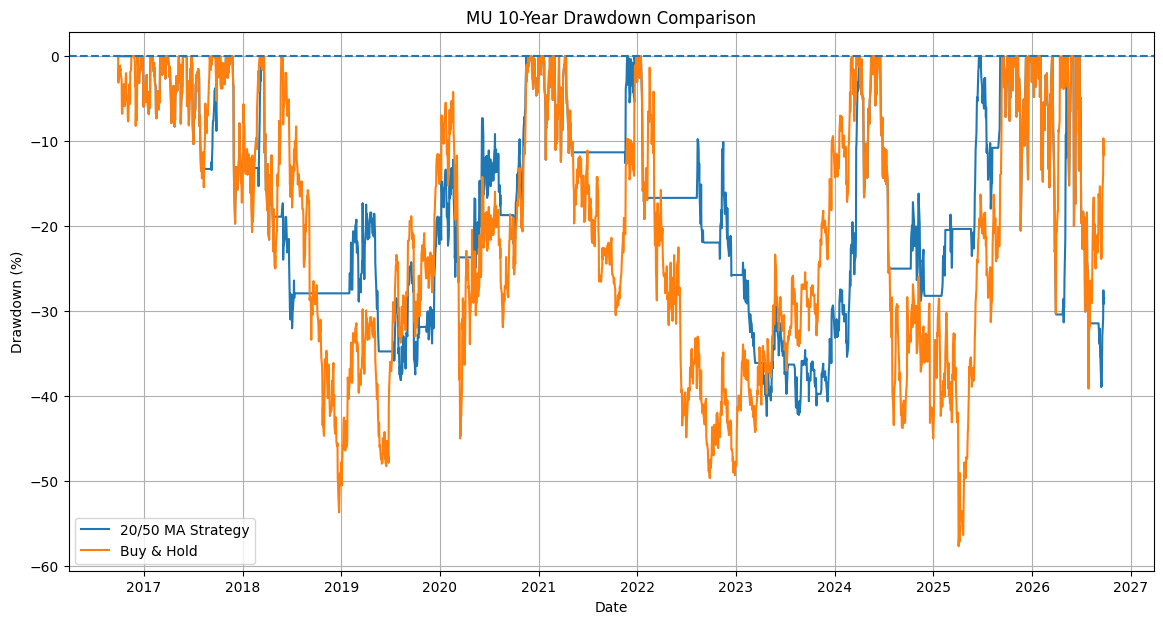

In [ ]:
# Step 18: 绘制 10 年回撤曲线 Drawdown Curve

plt.figure(figsize=(14, 7))

plt.plot(
    strategy_drawdown10.index,
    strategy_drawdown10 * 100,
    label="20/50 MA Strategy"
)

plt.plot(
    buy_hold_drawdown10.index,
    buy_hold_drawdown10 * 100,
    label="Buy & Hold"
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("MU 10-Year Drawdown Comparison")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Step 19: 计算最长回撤持续时间

def max_drawdown_duration(equity):

    peak = equity.cummax()
    underwater = equity < peak

    max_days = 0
    current_days = 0

    start_date = None
    max_start = None
    max_end = None

    for i in range(len(equity)):

        if underwater.iloc[i]:

            if current_days == 0:
                start_date = equity.index[i]

            current_days += 1

            if current_days > max_days:
                max_days = current_days
                max_start = start_date
                max_end = equity.index[i]

        else:
            current_days = 0
            start_date = None

    return max_days, max_start, max_end


strategy_duration = max_drawdown_duration(strategy_equity10)
buy_hold_duration = max_drawdown_duration(buy_hold_equity10)


print("=== 20/50 MA Strategy ===")
print("Longest drawdown:", strategy_duration[0], "trading days")
print("Start:", strategy_duration[1])
print("End:", strategy_duration[2])

print("\n=== Buy & Hold ===")
print("Longest drawdown:", buy_hold_duration[0], "trading days")
print("Start:", buy_hold_duration[1])
print("End:", buy_hold_duration[2])

=== 20/50 MA Strategy ===
Longest drawdown: 670 trading days
Start: 2018-03-21 00:00:00
End: 2020-11-13 00:00:00

=== Buy & Hold ===
Longest drawdown: 627 trading days
Start: 2018-05-30 00:00:00
End: 2020-11-20 00:00:00


In [ ]:
# Step 20: Train / Test Split

train_end = "2022-12-31"

train_data = data10.loc[:train_end].copy()
test_data = data10.loc["2023-01-01":].copy()

print("=== TRAIN DATA ===")
print("Start:", train_data.index[0])
print("End:", train_data.index[-1])
print("Trading days:", len(train_data))

print("\n=== TEST DATA ===")
print("Start:", test_data.index[0])
print("End:", test_data.index[-1])
print("Trading days:", len(test_data))

print("\nTotal:")
print(len(train_data) + len(test_data))

=== TRAIN DATA ===
Start: 2016-09-26 00:00:00
End: 2022-12-30 00:00:00
Trading days: 1578

=== TEST DATA ===
Start: 2023-01-03 00:00:00
End: 2026-09-25 00:00:00
Trading days: 936

Total:
2514


In [ ]:
# Step 21: 只在 TRAIN 数据测试不同 MA 参数

def backtest_ma(data, fast, slow,
                initial_cash=10000,
                commission=0.0005,
                slippage=0.0005):

    close = data["Close"]["MU"]
    open_price = data["Open"]["MU"]

    fast_ma = close.rolling(fast).mean()
    slow_ma = close.rolling(slow).mean()

    signal = (fast_ma > slow_ma).astype(int)

    buy_signal = (signal == 1) & (signal.shift(1) == 0)
    sell_signal = (signal == 0) & (signal.shift(1) == 1)

    cash = initial_cash
    shares = 0
    equity_values = []
    completed_trades = 0
    winning_trades = 0

    entry_value = None

    for i in range(len(data)):

        # 昨天 BUY signal → 今天 Open 买
        if i > 0 and buy_signal.iloc[i - 1] and shares == 0:

            buy_price = open_price.iloc[i] * (1 + slippage)

            investable_cash = cash / (1 + commission)
            shares = investable_cash / buy_price

            entry_value = shares * buy_price * (1 + commission)
            cash = 0

        # 昨天 SELL signal → 今天 Open 卖
        elif i > 0 and sell_signal.iloc[i - 1] and shares > 0:

            sell_price = open_price.iloc[i] * (1 - slippage)

            gross_value = shares * sell_price
            fee = gross_value * commission

            cash = gross_value - fee

            trade_return = cash / entry_value - 1

            completed_trades += 1

            if trade_return > 0:
                winning_trades += 1

            shares = 0
            entry_value = None

        # 每日账户价值
        if shares > 0:
            equity = shares * close.iloc[i]
        else:
            equity = cash

        equity_values.append(equity)

    equity = pd.Series(equity_values, index=data.index)

    daily_returns = equity.pct_change().fillna(0)

    years = (data.index[-1] - data.index[0]).days / 365.25

    cagr = (equity.iloc[-1] / initial_cash) ** (1 / years) - 1

    volatility = daily_returns.std() * np.sqrt(252)

    sharpe = (
        daily_returns.mean() /
        daily_returns.std()
    ) * np.sqrt(252)

    drawdown = equity / equity.cummax() - 1
    max_drawdown = drawdown.min()

    win_rate = (
        winning_trades / completed_trades
        if completed_trades > 0
        else np.nan
    )

    return {
        "Fast MA": fast,
        "Slow MA": slow,
        "CAGR": cagr,
        "Volatility": volatility,
        "Sharpe": sharpe,
        "Max Drawdown": max_drawdown,
        "Trades": completed_trades,
        "Win Rate": win_rate
    }


parameters = [
    (10, 30),
    (20, 50),
    (30, 100),
    (50, 200)
]

train_results = []

for fast, slow in parameters:
    result = backtest_ma(
        train_data,
        fast,
        slow
    )

    train_results.append(result)

train_results_df = pd.DataFrame(train_results)

display(train_results_df)

,Fast MA,Slow MA,CAGR,Volatility,Sharpe,Max Drawdown,Trades,Win Rate
0,10,30,0.070324,0.320828,0.372105,-0.517058,29,0.413793
1,20,50,0.212844,0.314933,0.769631,-0.381085,13,0.615385
2,30,100,0.063074,0.345616,0.351132,-0.575249,9,0.444444
3,50,200,0.019362,0.345127,0.229426,-0.483621,6,0.500000


In [ ]:
# Step 22: Out-of-Sample Test
# 不修改参数，直接测试 20/50

test_result = backtest_ma(
    test_data,
    fast=20,
    slow=50
)

test_result_df = pd.DataFrame(
    [test_result],
    index=["TEST 2023-2026"]
)

display(test_result_df)

,Fast MA,Slow MA,CAGR,Volatility,Sharpe,Max Drawdown,Trades,Win Rate
TEST 2023-2026,20,50,0.782266,0.476242,1.453423,-0.389142,9,0.666667


In [ ]:
# Step 22B: Train vs Test

train_20_50 = backtest_ma(
    train_data,
    fast=20,
    slow=50
)

test_20_50 = backtest_ma(
    test_data,
    fast=20,
    slow=50
)

comparison = pd.DataFrame(
    [train_20_50, test_20_50],
    index=[
        "TRAIN 2016-2022",
        "TEST 2023-2026"
    ]
)

display(comparison)

,Fast MA,Slow MA,CAGR,Volatility,Sharpe,Max Drawdown,Trades,Win Rate
TRAIN 2016-2022,20,50,0.212844,0.314933,0.769631,-0.381085,13,0.615385
TEST 2023-2026,20,50,0.782266,0.476242,1.453423,-0.389142,9,0.666667


In [ ]:
# Step 23: 给 Test 加 Warm-up Period

test_start = pd.Timestamp("2023-01-03")

# 取 Test 开始前 60 个交易日作为预热数据
warmup_data = train_data.tail(60)

# 预热数据 + 正式 Test 数据
test_with_warmup = pd.concat([
    warmup_data,
    test_data
])

close_warm = test_with_warmup["Close"]["MU"]
open_warm = test_with_warmup["Open"]["MU"]

# 计算 20 / 50 均线
ma20_warm = close_warm.rolling(20).mean()
ma50_warm = close_warm.rolling(50).mean()

signal_warm = (ma20_warm > ma50_warm).astype(int)

buy_warm = (
    (signal_warm == 1) &
    (signal_warm.shift(1) == 0)
)

sell_warm = (
    (signal_warm == 0) &
    (signal_warm.shift(1) == 1)
)

print("Warm-up starts:", test_with_warmup.index[0])
print("Official test starts:", test_start)

print("\nMA20 on first test day:")
print(ma20_warm.loc[test_start])

print("\nMA50 on first test day:")
print(ma50_warm.loc[test_start])

print("\nSignal on first test day:")
print(signal_warm.loc[test_start])

Warm-up starts: 2022-10-06 00:00:00
Official test starts: 2023-01-03 00:00:00

MA20 on first test day:
51.329460334777835

MA50 on first test day:
54.098529205322265

Signal on first test day:
0


In [ ]:
# Step 24: Warm-up 后正式重新回测 TEST

cash = 10000
shares = 0

equity_test = []
test_trades = []

entry_value = None

for date in test_data.index:

    i = test_with_warmup.index.get_loc(date)

    # 昨天产生 BUY signal → 今天 Open 买入
    if i > 0 and buy_warm.iloc[i - 1] and shares == 0:

        buy_price = open_warm.iloc[i] * (1 + slippage)

        investable_cash = cash / (1 + commission)
        shares = investable_cash / buy_price

        entry_value = shares * buy_price * (1 + commission)
        cash = 0

    # 昨天产生 SELL signal → 今天 Open 卖出
    elif i > 0 and sell_warm.iloc[i - 1] and shares > 0:

        sell_price = open_warm.iloc[i] * (1 - slippage)

        gross_value = shares * sell_price
        fee = gross_value * commission

        cash = gross_value - fee

        trade_return = cash / entry_value - 1
        test_trades.append(trade_return)

        shares = 0
        entry_value = None

    # 每日账户净值
    if shares > 0:
        equity = shares * close_warm.iloc[i]
    else:
        equity = cash

    equity_test.append(equity)


equity_test = pd.Series(
    equity_test,
    index=test_data.index
)

# ===== 计算指标 =====

test_daily_returns = equity_test.pct_change().fillna(0)

test_years = (
    equity_test.index[-1] -
    equity_test.index[0]
).days / 365.25

test_cagr = (
    equity_test.iloc[-1] /
    equity_test.iloc[0]
) ** (1 / test_years) - 1

test_vol = (
    test_daily_returns.std() *
    np.sqrt(252)
)

test_sharpe = (
    test_daily_returns.mean() /
    test_daily_returns.std()
) * np.sqrt(252)

test_drawdown = (
    equity_test /
    equity_test.cummax()
) - 1

test_mdd = test_drawdown.min()

test_win_rate = (
    np.mean(np.array(test_trades) > 0)
    if len(test_trades) > 0
    else np.nan
)

print("=== WARM-UP TEST RESULT ===")
print(f"Final Value: ${equity_test.iloc[-1]:,.2f}")
print(f"CAGR: {test_cagr:.2%}")
print(f"Volatility: {test_vol:.2%}")
print(f"Sharpe Ratio: {test_sharpe:.2f}")
print(f"Maximum Drawdown: {test_mdd:.2%}")
print(f"Completed Trades: {len(test_trades)}")
print(f"Win Rate: {test_win_rate:.2%}")

=== WARM-UP TEST RESULT ===
Final Value: $74,135.44
CAGR: 71.19%
Volatility: 48.04%
Sharpe Ratio: 1.36
Maximum Drawdown: -38.91%
Completed Trades: 10
Win Rate: 60.00%


In [ ]:
# Step 25: TEST 期间的 Buy & Hold Benchmark

test_close = test_data["Close"]["MU"]
test_open = test_data["Open"]["MU"]

benchmark_cash = 10000

# 第一个 Test 交易日开盘买入
benchmark_buy_price = test_open.iloc[0] * (1 + slippage)

# 考虑买入手续费
investable_cash = benchmark_cash / (1 + commission)
benchmark_shares = investable_cash / benchmark_buy_price

# 每日账户价值
benchmark_equity_test = benchmark_shares * test_close

# 每日收益率
benchmark_daily_returns = (
    benchmark_equity_test
    .pct_change()
    .fillna(0)
)

# CAGR
benchmark_cagr = (
    benchmark_equity_test.iloc[-1] /
    benchmark_cash
) ** (1 / test_years) - 1

# 年化波动率
benchmark_vol = (
    benchmark_daily_returns.std()
    * np.sqrt(252)
)

# Sharpe Ratio
benchmark_sharpe = (
    benchmark_daily_returns.mean() /
    benchmark_daily_returns.std()
) * np.sqrt(252)

# Maximum Drawdown
benchmark_drawdown = (
    benchmark_equity_test /
    benchmark_equity_test.cummax()
) - 1

benchmark_mdd = benchmark_drawdown.min()


print("=== TEST BUY & HOLD ===")
print(f"Final Value: ${benchmark_equity_test.iloc[-1]:,.2f}")
print(f"CAGR: {benchmark_cagr:.2%}")
print(f"Volatility: {benchmark_vol:.2%}")
print(f"Sharpe Ratio: {benchmark_sharpe:.2f}")
print(f"Maximum Drawdown: {benchmark_mdd:.2%}")

=== TEST BUY & HOLD ===
Final Value: $217,079.17
CAGR: 128.41%
Volatility: 60.05%
Sharpe Ratio: 1.68
Maximum Drawdown: -57.63%


In [ ]:
# Step 25B: Out-of-Sample Strategy vs Benchmark

test_comparison = pd.DataFrame({

    "20/50 MA": [
        equity_test.iloc[-1],
        test_cagr,
        test_vol,
        test_sharpe,
        test_mdd
    ],

    "Buy & Hold": [
        benchmark_equity_test.iloc[-1],
        benchmark_cagr,
        benchmark_vol,
        benchmark_sharpe,
        benchmark_mdd
    ]

}, index=[
    "Final Value",
    "CAGR",
    "Volatility",
    "Sharpe Ratio",
    "Maximum Drawdown"
])

display(test_comparison)

,20/50 MA,Buy & Hold
Final Value,74135.444833,217079.167269
CAGR,0.711937,1.284056
Volatility,0.480354,0.600550
Sharpe Ratio,1.360783,1.681513
Maximum Drawdown,-0.389142,-0.576290


In [ ]:
# Step 26: 建立多股票股票池

tickers = [
    "MU",
    "NVDA",
    "TSM",
    "LLY",
    "TSLA"
]

portfolio_data = yf.download(
    tickers,
    period="10y",
    auto_adjust=True,
    progress=False
)

print("Stocks:", tickers)
print("Trading days:", len(portfolio_data))
print("Start:", portfolio_data.index[0])
print("End:", portfolio_data.index[-1])

print("\nAvailable data:")
print(portfolio_data.columns)

print("\nLatest closing prices:")
display(portfolio_data["Close"].tail())

Stocks: ['MU', 'NVDA', 'TSM', 'LLY', 'TSLA']
Trading days: 2514
Start: 2016-09-26 00:00:00
End: 2026-09-25 00:00:00

Available data:
MultiIndex([( 'Close',  'LLY'),
            ( 'Close',   'MU'),
            ( 'Close', 'NVDA'),
            ( 'Close', 'TSLA'),
            ( 'Close',  'TSM'),
            (  'High',  'LLY'),
            (  'High',   'MU'),
            (  'High', 'NVDA'),
            (  'High', 'TSLA'),
            (  'High',  'TSM'),
            (   'Low',  'LLY'),
            (   'Low',   'MU'),
            (   'Low', 'NVDA'),
            (   'Low', 'TSLA'),
            (   'Low',  'TSM'),
            (  'Open',  'LLY'),
            (  'Open',   'MU'),
            (  'Open', 'NVDA'),
            (  'Open', 'TSLA'),
            (  'Open',  'TSM'),
            ('Volume',  'LLY'),
            ('Volume',   'MU'),
            ('Volume', 'NVDA'),
            ('Volume', 'TSLA'),
            ('Volume',  'TSM')],
           names=['Price', 'Ticker'])

Latest closing prices:


Ticker,LLY,MU,NVDA,TSLA,TSM
Date,,,,,
2026-09-21,1164.890015,1043.959961,227.380005,375.299988,445.140015
2026-09-22,1170.140015,1096.160034,228.869995,378.899994,452.000000
2026-09-23,1150.989990,1071.880005,225.509995,380.119995,446.570007
2026-09-24,1181.890015,1080.530029,224.580002,377.940002,451.149994
2026-09-25,1183.459961,1082.280029,225.070007,372.109985,450.609985


In [ ]:
# Step 27: 多股票 20/50 MA 信号

close_multi = portfolio_data["Close"]

# 每只股票分别计算 MA20 和 MA50
ma20_multi = close_multi.rolling(20).mean()
ma50_multi = close_multi.rolling(50).mean()

# MA20 > MA50 = 1（持有）
# MA20 <= MA50 = 0（现金）
signals_multi = (ma20_multi > ma50_multi).astype(int)

# 查看最新一天
latest_date = signals_multi.index[-1]

latest_signals = pd.DataFrame({
    "Price": close_multi.loc[latest_date],
    "MA20": ma20_multi.loc[latest_date],
    "MA50": ma50_multi.loc[latest_date],
    "Signal": signals_multi.loc[latest_date]
})

# 把 1 / 0 转换成容易看的文字
latest_signals["Status"] = latest_signals["Signal"].map({
    1: "BUY / HOLD",
    0: "CASH"
})

print("Date:", latest_date)
display(latest_signals)

Date: 2026-09-25 00:00:00


,Price,MA20,MA50,Signal,Status
Ticker,,,,,
LLY,1183.459961,1150.807489,1176.735081,0,CASH
MU,1082.280029,994.142502,941.615203,1,BUY / HOLD
NVDA,225.070007,221.654555,215.794765,1,BUY / HOLD
TSLA,372.109985,365.684497,348.248598,1,BUY / HOLD
TSM,450.609985,429.509497,419.241794,1,BUY / HOLD


In [ ]:
# Step 28: Equal Weight Portfolio

active_signals = signals_multi.sum(axis=1)

# 每天有信号的股票平均分配资金
weights_equal = signals_multi.div(
    active_signals,
    axis=0
).fillna(0)

# 查看最新仓位
latest_weights = (
    weights_equal
    .loc[latest_date]
    .sort_values(ascending=False)
)

print("=== Latest Portfolio Weights ===")

for ticker, weight in latest_weights.items():
    print(f"{ticker}: {weight:.2%}")

cash_weight = 1 - latest_weights.sum()

print(f"CASH: {cash_weight:.2%}")

=== Latest Portfolio Weights ===
MU: 25.00%
TSLA: 25.00%
NVDA: 25.00%
TSM: 25.00%
LLY: 0.00%
CASH: 0.00%


In [ ]:
# Step 29: Momentum Factor

close_multi = portfolio_data["Close"]

# 过去 20 / 60 / 120 个交易日的收益率
momentum_20 = close_multi.pct_change(20)
momentum_60 = close_multi.pct_change(60)
momentum_120 = close_multi.pct_change(120)

# 查看最新一天的 Momentum
latest_momentum = pd.DataFrame({
    "Momentum 20D": momentum_20.iloc[-1],
    "Momentum 60D": momentum_60.iloc[-1],
    "Momentum 120D": momentum_120.iloc[-1]
})

# 转成百分比方便阅读
latest_momentum_display = latest_momentum * 100

print("=== Latest Momentum Factors (%) ===")
print("Date:", close_multi.index[-1])

display(
    latest_momentum_display
    .sort_values("Momentum 20D", ascending=False)
    .round(2)
)

=== Latest Momentum Factors (%) ===
Date: 2026-09-25 00:00:00


,Momentum 20D,Momentum 60D,Momentum 120D
Ticker,,,
MU,15.70,4.86,186.54
TSM,5.74,1.71,32.51
TSLA,4.88,-12.51,5.47
LLY,0.63,-0.55,28.06
NVDA,-1.17,14.04,26.99


In [ ]:
# Step 30: 创建未来 20 日收益率
# 用来检验今天的 Momentum 是否与未来收益有关

forward_return_20 = close_multi.shift(-20) / close_multi - 1

# 把 Momentum 和未来收益整理成长表
factor_test = pd.DataFrame({
    "Momentum20": momentum_20.stack(),
    "Momentum60": momentum_60.stack(),
    "Momentum120": momentum_120.stack(),
    "ForwardReturn20": forward_return_20.stack()
}).dropna()

print("=== Factor Test Dataset ===")
print("Number of observations:", len(factor_test))

display(factor_test.head(10))

=== Factor Test Dataset ===
Number of observations: 11870


Momentum20  Momentum60  Momentum120  ForwardReturn20
Date       Ticker                                                      
2017-03-20 LLY       0.045653    0.153253     0.071176        -0.034023
           MU        0.122484    0.269249     0.509792         0.035483
           NVDA      0.021991    0.042009     0.705816        -0.092828
           TSLA     -0.037872    0.254466     0.253266         0.146342
           TSM       0.015770    0.120778     0.100871        -0.032268
2017-03-21 LLY       0.041936    0.150764     0.049029        -0.033919
           MU        0.073622    0.240039     0.417778         0.068181
           NVDA     -0.045254    0.002018     0.596069        -0.058823
           TSLA     -0.096290    0.206933     0.218017         0.218765
           TSM       0.004640    0.114619     0.068421        -0.026786

In [ ]:
# Step 31: Momentum Factor IC Test
# 每一天比较 5 只股票：
# Momentum 排名 vs 未来20日收益排名

ic_results = []

for date, group in factor_test.groupby(level="Date"):

    # 至少需要 3 只股票才能计算
    if len(group) >= 3:

        ic20 = group["Momentum20"].corr(
            group["ForwardReturn20"],
            method="spearman"
        )

        ic60 = group["Momentum60"].corr(
            group["ForwardReturn20"],
            method="spearman"
        )

        ic120 = group["Momentum120"].corr(
            group["ForwardReturn20"],
            method="spearman"
        )

        ic_results.append({
            "Date": date,
            "IC20": ic20,
            "IC60": ic60,
            "IC120": ic120
        })

ic_df = pd.DataFrame(ic_results).set_index("Date")

print("=== Momentum Factor IC Test ===")

print("\nAverage IC:")
print(ic_df.mean().round(4))

print("\nIC Standard Deviation:")
print(ic_df.std().round(4))

print("\nPositive IC Ratio:")
print((ic_df > 0).mean().round(4))

display(ic_df.tail())

=== Momentum Factor IC Test ===

Average IC:
IC20     0.0237
IC60     0.0420
IC120    0.0488
dtype: float64

IC Standard Deviation:
IC20     0.5170
IC60     0.5253
IC120    0.5314
dtype: float64

Positive IC Ratio:
IC20     0.4878
IC60     0.5274
IC120    0.5156
dtype: float64


,IC20,IC60,IC120
Date,,,
2026-08-21,-0.5,-0.1,0.3
2026-08-24,-0.7,-0.1,0.4
2026-08-25,0.8,-0.9,0.1
2026-08-26,1.0,-0.8,0.1
2026-08-27,-0.3,-0.6,0.3


In [ ]:
# Step 32: Momentum Ranking Test
# 检查 Momentum 越高，未来20日收益是否也越高

rank_test = factor_test[
    ["Momentum120", "ForwardReturn20"]
].copy()

# 每一天把 5 只股票按照 Momentum120 从低到高排名
rank_test["MomentumRank"] = (
    rank_test
    .groupby(level="Date")["Momentum120"]
    .rank(method="first")
)

# 每个排名对应的平均未来20日收益
rank_returns = (
    rank_test
    .groupby("MomentumRank")["ForwardReturn20"]
    .agg(["mean", "median", "count"])
)

rank_returns["mean"] *= 100
rank_returns["median"] *= 100

print("=== 120D Momentum Ranking Test ===")
print("Rank 1 = Weakest Momentum")
print("Rank 5 = Strongest Momentum")

display(rank_returns.round(2))

=== 120D Momentum Ranking Test ===
Rank 1 = Weakest Momentum
Rank 5 = Strongest Momentum


,mean,median,count
MomentumRank,,,
1.0,3.40,2.66,2374
2.0,2.73,1.92,2374
3.0,3.18,2.39,2374
4.0,2.82,2.66,2374
5.0,6.40,3.63,2374


In [ ]:
# Step 33: 120D Momentum - Train vs Test Validation

# 时间分界
split_date = pd.Timestamp("2023-01-01")

# 分开 Train 和 Test
factor_train = factor_test[
    factor_test.index.get_level_values("Date") < split_date
].copy()

factor_test_oos = factor_test[
    factor_test.index.get_level_values("Date") >= split_date
].copy()


def momentum_rank_test(df):

    temp = df[
        ["Momentum120", "ForwardReturn20"]
    ].copy()

    # 每天按照 120D Momentum 从低到高排名
    temp["MomentumRank"] = (
        temp
        .groupby(level="Date")["Momentum120"]
        .rank(method="first")
    )

    result = (
        temp
        .groupby("MomentumRank")["ForwardReturn20"]
        .agg(["mean", "median", "count"])
    )

    # 转换成百分比
    result["mean"] *= 100
    result["median"] *= 100

    return result


train_rank = momentum_rank_test(factor_train)
test_rank = momentum_rank_test(factor_test_oos)


print("=== TRAIN: 120D Momentum ===")
print("Rank 1 = Weakest")
print("Rank 5 = Strongest")
display(train_rank.round(2))


print("\n=== TEST: 120D Momentum ===")
print("Rank 1 = Weakest")
print("Rank 5 = Strongest")
display(test_rank.round(2))

=== TRAIN: 120D Momentum ===
Rank 1 = Weakest
Rank 5 = Strongest


,mean,median,count
MomentumRank,,,
1.0,2.61,2.55,1458
2.0,1.44,1.31,1458
3.0,2.37,1.87,1458
4.0,2.82,3.11,1458
5.0,5.05,2.56,1458



=== TEST: 120D Momentum ===
Rank 1 = Weakest
Rank 5 = Strongest


,mean,median,count
MomentumRank,,,
1.0,4.67,2.70,916
2.0,4.79,3.28,916
3.0,4.47,3.22,916
4.0,2.82,2.27,916
5.0,8.55,5.56,916


In [ ]:
# Step 34: Volatility Factor

# 每日收益率
daily_returns_multi = close_multi.pct_change()

# 过去20个交易日波动率，并进行年化
volatility_20 = (
    daily_returns_multi
    .rolling(20)
    .std()
    * np.sqrt(252)
)

# 查看最新一天
latest_volatility = (
    volatility_20
    .iloc[-1]
    .sort_values()
    * 100
)

print("=== Latest 20D Annualized Volatility (%) ===")
print("Date:", close_multi.index[-1])

display(
    latest_volatility
    .round(2)
    .to_frame("Volatility 20D")
)

=== Latest 20D Annualized Volatility (%) ===
Date: 2026-09-25 00:00:00


,Volatility 20D
Ticker,
LLY,18.39
TSM,27.85
NVDA,32.21
TSLA,44.03
MU,50.40


In [ ]:
# Step 35: Volatility Factor Validation

vol_factor_test = pd.DataFrame({
    "Volatility20": volatility_20.stack(),
    "ForwardReturn20": forward_return_20.stack()
}).dropna()

# 每天计算 Spearman IC
vol_ic_results = []

for date, group in vol_factor_test.groupby(level="Date"):

    if len(group) >= 3:

        ic = group["Volatility20"].corr(
            group["ForwardReturn20"],
            method="spearman"
        )

        vol_ic_results.append({
            "Date": date,
            "IC": ic
        })

vol_ic_df = pd.DataFrame(
    vol_ic_results
).set_index("Date")

print("=== Volatility Factor IC Test ===")

print("\nAverage IC:")
print(round(vol_ic_df["IC"].mean(), 4))

print("\nIC Standard Deviation:")
print(round(vol_ic_df["IC"].std(), 4))

print("\nPositive IC Ratio:")
print(round((vol_ic_df["IC"] > 0).mean(), 4))

=== Volatility Factor IC Test ===

Average IC:
0.0241

IC Standard Deviation:
0.5331

Positive IC Ratio:
0.4976


In [ ]:
# Step 36: Volatility Factor - Train vs Test

split_date = pd.Timestamp("2023-01-01")

vol_train = vol_factor_test[
    vol_factor_test.index.get_level_values("Date") < split_date
].copy()

vol_test = vol_factor_test[
    vol_factor_test.index.get_level_values("Date") >= split_date
].copy()


def calculate_vol_ic(df):

    daily_ic = []

    for date, group in df.groupby(level="Date"):

        if len(group) >= 3:

            ic = group["Volatility20"].corr(
                group["ForwardReturn20"],
                method="spearman"
            )

            daily_ic.append(ic)

    daily_ic = pd.Series(daily_ic).dropna()

    return {
        "Average IC": daily_ic.mean(),
        "IC Std": daily_ic.std(),
        "Positive IC Ratio": (daily_ic > 0).mean()
    }


vol_train_result = calculate_vol_ic(vol_train)
vol_test_result = calculate_vol_ic(vol_test)

comparison = pd.DataFrame({
    "TRAIN": vol_train_result,
    "TEST": vol_test_result
})

print("=== Volatility20 Train vs Test ===")
display(comparison.round(4))

=== Volatility20 Train vs Test ===


,TRAIN,TEST
Average IC,0.0236,0.0250
IC Std,0.5384,0.5243
Positive IC Ratio,0.5096,0.4771


In [ ]:
# Step 37: Volume Factor

volume_multi = portfolio_data["Volume"]

# 过去20日平均成交量
avg_volume_20 = volume_multi.rolling(20).mean()

# 当前成交量 / 20日平均成交量
volume_factor = volume_multi / avg_volume_20

# 查看最新一天
latest_volume_factor = (
    volume_factor
    .iloc[-1]
    .sort_values(ascending=False)
)

print("=== Latest Volume Factor ===")
print("Date:", volume_factor.index[-1])

display(
    latest_volume_factor
    .round(2)
    .to_frame("Volume Factor")
)

=== Latest Volume Factor ===
Date: 2026-09-25 00:00:00


,Volume Factor
Ticker,
TSLA,1.16
MU,0.83
LLY,0.82
TSM,0.79
NVDA,0.77


In [ ]:
# Step 38: Volume Factor IC Test

volume_factor_test = pd.DataFrame({
    "VolumeFactor": volume_factor.stack(),
    "ForwardReturn20": forward_return_20.stack()
}).dropna()

# 每天计算横截面 Spearman IC
volume_ic_results = []

for date, group in volume_factor_test.groupby(level="Date"):

    if len(group) >= 3:

        ic = group["VolumeFactor"].corr(
            group["ForwardReturn20"],
            method="spearman"
        )

        volume_ic_results.append({
            "Date": date,
            "IC": ic
        })

volume_ic_df = pd.DataFrame(
    volume_ic_results
).set_index("Date")

print("=== Volume Factor IC Test ===")

print("\nAverage IC:")
print(round(volume_ic_df["IC"].mean(), 4))

print("\nIC Standard Deviation:")
print(round(volume_ic_df["IC"].std(), 4))

print("\nPositive IC Ratio:")
print(round((volume_ic_df["IC"] > 0).mean(), 4))

=== Volume Factor IC Test ===

Average IC:
-0.0044

IC Standard Deviation:
0.5063

Positive IC Ratio:
0.4703


In [ ]:
# Step 39: Volume Factor - Train vs Test

split_date = pd.Timestamp("2023-01-01")

volume_train = volume_factor_test[
    volume_factor_test.index.get_level_values("Date") < split_date
].copy()

volume_test = volume_factor_test[
    volume_factor_test.index.get_level_values("Date") >= split_date
].copy()


def calculate_volume_ic(df):

    daily_ic = []

    for date, group in df.groupby(level="Date"):

        if len(group) >= 3:

            ic = group["VolumeFactor"].corr(
                group["ForwardReturn20"],
                method="spearman"
            )

            daily_ic.append(ic)

    daily_ic = pd.Series(daily_ic).dropna()

    return {
        "Average IC": daily_ic.mean(),
        "IC Std": daily_ic.std(),
        "Positive IC Ratio": (daily_ic > 0).mean()
    }


volume_train_result = calculate_volume_ic(volume_train)
volume_test_result = calculate_volume_ic(volume_test)

volume_comparison = pd.DataFrame({
    "TRAIN": volume_train_result,
    "TEST": volume_test_result
})

print("=== Volume Factor Train vs Test ===")
display(volume_comparison.round(4))

=== Volume Factor Train vs Test ===


,TRAIN,TEST
Average IC,-0.0139,0.0119
IC Std,0.5064,0.5061
Positive IC Ratio,0.4638,0.4814


In [ ]:
# Step 40: Momentum + Volume Interaction

interaction = pd.DataFrame({
    "Momentum120": momentum_120.stack(),
    "VolumeFactor": volume_factor.stack(),
    "ForwardReturn20": forward_return_20.stack()
}).dropna()

# 每天计算 Momentum 百分位排名
interaction["MomentumPctRank"] = (
    interaction
    .groupby(level="Date")["Momentum120"]
    .rank(pct=True)
)

# 只保留每天 Momentum 最强的前40%
strong_momentum = interaction[
    interaction["MomentumPctRank"] > 0.60
].copy()

# 在强 Momentum 股票中：
# VolumeFactor > 1 = 成交量高于20日平均
strong_momentum["VolumeGroup"] = np.where(
    strong_momentum["VolumeFactor"] > 1,
    "High Volume",
    "Normal/Low Volume"
)

interaction_result = (
    strong_momentum
    .groupby("VolumeGroup")["ForwardReturn20"]
    .agg(["mean", "median", "count"])
)

interaction_result["mean"] *= 100
interaction_result["median"] *= 100

print("=== Momentum120 + Volume Interaction ===")
display(interaction_result.round(2))

=== Momentum120 + Volume Interaction ===


,mean,median,count
VolumeGroup,,,
High Volume,4.77,3.46,1928
Normal/Low Volume,4.50,2.82,2820


In [ ]:
# Step 41: Momentum + Volume Interaction
# Train vs Test

split_date = pd.Timestamp("2023-01-01")

interaction_train = strong_momentum[
    strong_momentum.index.get_level_values("Date") < split_date
].copy()

interaction_test = strong_momentum[
    strong_momentum.index.get_level_values("Date") >= split_date
].copy()


def interaction_summary(df):

    result = (
        df
        .groupby("VolumeGroup")["ForwardReturn20"]
        .agg(["mean", "median", "count"])
    )

    result["mean"] *= 100
    result["median"] *= 100

    return result


train_interaction = interaction_summary(interaction_train)
test_interaction = interaction_summary(interaction_test)


print("=== TRAIN: Momentum + Volume ===")
display(train_interaction.round(2))

print("\n=== TEST: Momentum + Volume ===")
display(test_interaction.round(2))

=== TRAIN: Momentum + Volume ===


,mean,median,count
VolumeGroup,,,
High Volume,4.39,3.50,1169
Normal/Low Volume,3.63,2.29,1747



=== TEST: Momentum + Volume ===


,mean,median,count
VolumeGroup,,,
High Volume,5.35,3.19,759
Normal/Low Volume,5.93,3.74,1073


In [ ]:
# Step 42: V0.1 Factor Registry

factor_registry = pd.DataFrame({
    "Factor": [
        "Momentum120",
        "Volatility20",
        "Volume20",
        "Momentum x Volume",
        "Earnings Growth"
    ],

    "Category": [
        "Alpha",
        "Risk",
        "Alpha",
        "Interaction",
        "Alpha"
    ],

    "Status": [
        "Candidate",
        "Keep for Position Sizing",
        "Rejected",
        "Rejected",
        "To Test"
    ],

    "Reason": [
        "Rank 5 strongest in Train and Test",
        "Weak alpha IC, useful as risk measure",
        "IC near zero",
        "Failed out-of-sample validation",
        "Need point-in-time fundamental data"
    ]
})

print("=== V0.1 Factor Registry ===")
display(factor_registry)

=== V0.1 Factor Registry ===


,Factor,Category,Status,Reason
0,Momentum120,Alpha,Candidate,Rank 5 strongest in Train and Test
1,Volatility20,Risk,Keep for Position Sizing,"Weak alpha IC, useful as risk measure"
2,Volume20,Alpha,Rejected,IC near zero
3,Momentum x Volume,Interaction,Rejected,Failed out-of-sample validation
4,Earnings Growth,Alpha,To Test,Need point-in-time fundamental data


In [ ]:
# Step 43: Inspect Historical Fundamental Data

mu = yf.Ticker("MU")

# 季度利润表
mu_income = mu.quarterly_income_stmt

print("=== MU Quarterly Income Statement ===")
print("Number of quarters:", len(mu_income.columns))
print("\nAvailable financial fields:")

for item in mu_income.index:
    print(item)

print("\nQuarter dates:")
print(mu_income.columns)

=== MU Quarterly Income Statement ===
Number of quarters: 5

Available financial fields:
Tax Effect Of Unusual Items
Tax Rate For Calcs
Normalized EBITDA
Net Income From Continuing Operation Net Minority Interest
Reconciled Depreciation
Reconciled Cost Of Revenue
EBITDA
EBIT
Net Interest Income
Interest Expense
Interest Income
Normalized Income
Net Income From Continuing And Discontinued Operation
Total Expenses
Total Operating Income As Reported
Diluted Average Shares
Basic Average Shares
Diluted EPS
Basic EPS
Diluted NI Availto Com Stockholders
Net Income Common Stockholders
Net Income
Net Income Including Noncontrolling Interests
Net Income Continuous Operations
Earnings From Equity Interest Net Of Tax
Tax Provision
Pretax Income
Other Income Expense
Other Non Operating Income Expenses
Net Non Operating Interest Income Expense
Interest Expense Non Operating
Interest Income Non Operating
Operating Income
Operating Expense
Other Operating Expenses
Research And Development
Selling Gene

In [47]:
# Step 44: Get MU Historical SEC Filing Dates

mu = yf.Ticker("MU")

# 获取 SEC filings
mu_filings = mu.sec_filings

print("=== MU SEC Filings ===")
print("Number of filings:", len(mu_filings))

# 先查看前几个 filing
for filing in mu_filings[:10]:
    print(filing)

=== MU SEC Filings ===
Number of filings: 93
{'date': datetime.date(2026, 8, 26), 'epochDate': 1787702400, 'type': '8-K', 'title': 'Corporate Changes & Voting Matters', 'edgarUrl': 'https://finance.yahoo.com/sec-filing/MU/0001104659-26-101067_723125', 'exhibits': {'8-K': 'https://cdn.yahoofinance.com/prod/sec-filings/0000723125/000110465926101067/tm2624017d1_8k.htm', 'EX-99.1': 'https://cdn.yahoofinance.com/prod/sec-filings/0000723125/000110465926101067/tm2624017d1_ex99-1.htm'}, 'maxAge': 1}
{'date': datetime.date(2026, 6, 25), 'epochDate': 1782345600, 'type': '10-Q', 'title': 'Periodic Financial Reports', 'edgarUrl': 'https://finance.yahoo.com/sec-filing/MU/0000723125-26-000015_723125', 'exhibits': {'10-Q': 'https://cdn.yahoofinance.com/prod/sec-filings/0000723125/000072312526000015/mu-20260528.htm', 'EX-10.1': 'https://cdn.yahoofinance.com/prod/sec-filings/0000723125/000072312526000015/ex101-amendmentno3tothedir.htm', 'EX-10.2': 'https://cdn.yahoofinance.com/prod/sec-filings/00007231

In [48]:
# Step 45: Filter MU 10-Q and 10-K Filings

mu_financial_filings = [
    filing for filing in mu_filings
    if filing.get("type") in ["10-Q", "10-K"]
]

print("=== MU 10-Q / 10-K Filings ===")
print("Number of financial filings:", len(mu_financial_filings))

for filing in mu_financial_filings:
    print(
        filing.get("date"),
        "|",
        filing.get("type"),
        "|",
        filing.get("title")
    )

=== MU 10-Q / 10-K Filings ===
Number of financial filings: 18
2026-06-25 | 10-Q | Periodic Financial Reports
2026-03-19 | 10-Q | Periodic Financial Reports
2025-12-18 | 10-Q | Periodic Financial Reports
2025-10-03 | 10-K | Periodic Financial Reports
2025-06-26 | 10-Q | Periodic Financial Reports
2025-03-21 | 10-Q | Periodic Financial Reports
2024-12-19 | 10-Q | Periodic Financial Reports
2024-10-04 | 10-K | Periodic Financial Reports
2024-06-27 | 10-Q | Periodic Financial Reports
2024-03-21 | 10-Q | Periodic Financial Reports
2023-12-21 | 10-Q | Periodic Financial Reports
2023-10-06 | 10-K | Periodic Financial Reports
2023-06-29 | 10-Q | Periodic Financial Reports
2023-03-29 | 10-Q | Periodic Financial Reports
2022-12-22 | 10-Q | Periodic Financial Reports
2022-10-07 | 10-K | Periodic Financial Reports
2022-07-01 | 10-Q | Periodic Financial Reports
2022-03-30 | 10-Q | Periodic Financial Reports


In [49]:
# Step 46: Get MU Historical EPS from SEC Company Facts

import requests
import pandas as pd

# Micron Technology (MU) SEC CIK
cik = "0000723125"

url = f"https://data.sec.gov/api/xbrl/companyfacts/CIK{cik}.json"

# SEC requires an identifiable User-Agent
headers = {
    "User-Agent": "QuantResearchProject z5664706@ad.unsw.edu.au"
}

response = requests.get(url, headers=headers)
response.raise_for_status()

sec_data = response.json()

print("Company:", sec_data["entityName"])

# Diluted EPS
eps_data = sec_data["facts"]["us-gaap"]["EarningsPerShareDiluted"]["units"]["USD/shares"]

eps_df = pd.DataFrame(eps_data)

# Keep 10-Q / 10-K filings
eps_df = eps_df[
    eps_df["form"].isin(["10-Q", "10-K"])
].copy()

# Convert dates
eps_df["end"] = pd.to_datetime(eps_df["end"])
eps_df["filed"] = pd.to_datetime(eps_df["filed"])

# Keep useful columns
eps_df = eps_df[
    ["start", "end", "filed", "form", "fy", "fp", "val"]
].sort_values("filed")

print("\n=== MU Historical Diluted EPS ===")
print("Number of EPS records:", len(eps_df))
print("Earliest filing:", eps_df["filed"].min())
print("Latest filing:", eps_df["filed"].max())

display(eps_df.tail(20))

Company: Micron Technology, Inc.

=== MU Historical Diluted EPS ===
Number of EPS records: 287
Earliest filing: 2010-01-12 00:00:00
Latest filing: 2026-06-25 00:00:00


,start,end,filed,form,fy,fp,val
295,2024-08-30,2025-02-27,2025-03-21,10-Q,2025.0,Q2,3.08
286,2023-12-01,2024-02-29,2025-03-21,10-Q,2025.0,Q2,0.71
297,2024-11-29,2025-02-27,2025-03-21,10-Q,2025.0,Q2,1.41
288,2023-09-01,2024-05-30,2025-06-26,10-Q,2025.0,Q3,-0.10
290,2024-03-01,2024-05-30,2025-06-26,10-Q,2025.0,Q3,0.30
301,2025-02-28,2025-05-29,2025-06-26,10-Q,2025.0,Q3,1.68
299,2024-08-30,2025-05-29,2025-06-26,10-Q,2025.0,Q3,4.75
303,2024-08-30,2025-08-28,2025-10-03,10-K,2025.0,FY,7.59
280,2022-09-02,2023-08-31,2025-10-03,10-K,2025.0,FY,-5.34
292,2023-09-01,2024-08-29,2025-10-03,10-K,2025.0,FY,0.70


In [50]:
# Step 47: Clean SEC EPS Data - Keep Single-Quarter EPS

eps_clean = eps_df.copy()

# Convert start to datetime
eps_clean["start"] = pd.to_datetime(eps_clean["start"])

# Calculate reporting period length
eps_clean["period_days"] = (
    eps_clean["end"] - eps_clean["start"]
).dt.days

# Keep roughly one-quarter reporting periods
eps_quarterly = eps_clean[
    (eps_clean["period_days"] >= 75) &
    (eps_clean["period_days"] <= 105)
].copy()

# Keep our research period
eps_quarterly = eps_quarterly[
    eps_quarterly["filed"] >= "2016-01-01"
].copy()

eps_quarterly = eps_quarterly.sort_values("filed")

print("=== MU Clean Quarterly EPS ===")
print("Number of quarterly EPS records:", len(eps_quarterly))
print("Earliest filing:", eps_quarterly["filed"].min())
print("Latest filing:", eps_quarterly["filed"].max())

display(
    eps_quarterly[
        ["start", "end", "filed", "form", "fy", "fp", "val", "period_days"]
    ].tail(20)
)

=== MU Clean Quarterly EPS ===
Number of quarterly EPS records: 106
Earliest filing: 2016-01-08 00:00:00
Latest filing: 2026-06-25 00:00:00


,start,end,filed,form,fy,fp,val,period_days
276,2023-03-03,2023-06-01,2023-06-29,10-Q,2023.0,Q3,-1.73,90
264,2022-03-04,2022-06-02,2023-06-29,10-Q,2023.0,Q3,2.34,90
269,2022-09-02,2022-12-01,2023-12-21,10-Q,2024.0,Q1,-0.18,90
281,2023-09-01,2023-11-30,2023-12-21,10-Q,2024.0,Q1,-1.12,90
285,2023-12-01,2024-02-29,2024-03-21,10-Q,2024.0,Q2,0.71,90
273,2022-12-02,2023-03-02,2024-03-21,10-Q,2024.0,Q2,-2.12,90
289,2024-03-01,2024-05-30,2024-06-27,10-Q,2024.0,Q3,0.30,90
277,2023-03-03,2023-06-01,2024-06-27,10-Q,2024.0,Q3,-1.73,90
293,2024-08-30,2024-11-28,2024-12-19,10-Q,2025.0,Q1,1.67,90
282,2023-09-01,2023-11-30,2024-12-19,10-Q,2025.0,Q1,-1.12,90


In [51]:
# Step 48: Keep First Available EPS for Each Quarter
# Prevent later filings from rewriting historical information

eps_pit = (
    eps_quarterly
    .sort_values("filed")
    .drop_duplicates(
        subset=["start", "end"],
        keep="first"
    )
    .copy()
)

eps_pit = eps_pit.sort_values("filed")

print("=== MU Point-in-Time Quarterly EPS ===")
print("Before removing duplicates:", len(eps_quarterly))
print("After removing duplicates:", len(eps_pit))

print("Earliest filing:", eps_pit["filed"].min())
print("Latest filing:", eps_pit["filed"].max())

display(
    eps_pit[
        ["start", "end", "filed", "form", "fy", "fp", "val"]
    ].tail(20)
)

=== MU Point-in-Time Quarterly EPS ===
Before removing duplicates: 106
After removing duplicates: 42
Earliest filing: 2016-01-08 00:00:00
Latest filing: 2026-06-25 00:00:00


,start,end,filed,form,fy,fp,val
235,2020-02-28,2020-05-28,2020-06-29,10-Q,2020.0,Q3,0.71
241,2020-05-29,2020-09-03,2020-10-19,10-K,2020.0,FY,0.87
242,2020-09-04,2020-12-03,2021-01-08,10-Q,2021.0,Q1,0.71
246,2020-12-04,2021-03-04,2021-04-01,10-Q,2021.0,Q2,0.53
250,2021-03-05,2021-06-03,2021-07-01,10-Q,2021.0,Q3,1.52
255,2021-09-03,2021-12-02,2022-01-06,10-Q,2022.0,Q1,2.04
259,2021-12-03,2022-03-03,2022-03-30,10-Q,2022.0,Q2,2.00
263,2022-03-04,2022-06-02,2022-07-01,10-Q,2022.0,Q3,2.34
268,2022-09-02,2022-12-01,2022-12-22,10-Q,2023.0,Q1,-0.18
272,2022-12-02,2023-03-02,2023-03-29,10-Q,2023.0,Q2,-2.12


In [52]:
# Step 49: Calculate Year-over-Year EPS Growth

eps_growth = eps_pit.copy()

# Sort by actual fiscal quarter end
eps_growth = eps_growth.sort_values("end")

# EPS from the same quarter one year ago
eps_growth["EPS_1Y_Ago"] = eps_growth["val"].shift(4)

# Raw EPS change
eps_growth["EPS_Change"] = (
    eps_growth["val"] - eps_growth["EPS_1Y_Ago"]
)

# Normalized YoY EPS growth
eps_growth["EarningsGrowth"] = (
    eps_growth["EPS_Change"] /
    eps_growth["EPS_1Y_Ago"].abs()
)

print("=== MU Earnings Growth Factor ===")

display(
    eps_growth[
        [
            "end",
            "filed",
            "val",
            "EPS_1Y_Ago",
            "EarningsGrowth"
        ]
    ].tail(20)
)

=== MU Earnings Growth Factor ===


,end,filed,val,EPS_1Y_Ago,EarningsGrowth
235,2020-05-28,2020-06-29,0.71,0.74,-0.040541
241,2020-09-03,2020-10-19,0.87,0.49,0.775510
242,2020-12-03,2021-01-08,0.71,0.43,0.651163
246,2021-03-04,2021-04-01,0.53,0.36,0.472222
250,2021-06-03,2021-07-01,1.52,0.71,1.140845
255,2021-12-02,2022-01-06,2.04,0.87,1.344828
259,2022-03-03,2022-03-30,2.00,0.71,1.816901
263,2022-06-02,2022-07-01,2.34,0.53,3.415094
268,2022-12-01,2022-12-22,-0.18,1.52,-1.118421
272,2023-03-02,2023-03-29,-2.12,2.04,-2.039216


In [53]:
# Step 50: Download Point-in-Time EPS for US Stocks

import requests
import pandas as pd

company_ciks = {
    "MU":   "0000723125",
    "NVDA": "0001045810",
    "TSLA": "0001318605",
    "LLY":  "0000059478"
}

headers = {
    "User-Agent": "QuantResearchProject z5664706@ad.unsw.edu.au"
}

all_eps = {}

for ticker, cik in company_ciks.items():

    url = f"https://data.sec.gov/api/xbrl/companyfacts/CIK{cik}.json"

    response = requests.get(url, headers=headers)
    response.raise_for_status()

    data = response.json()

    try:
        eps_raw = (
            data["facts"]["us-gaap"]
            ["EarningsPerShareDiluted"]
            ["units"]["USD/shares"]
        )

        df = pd.DataFrame(eps_raw)

        # Keep 10-Q / 10-K only
        df = df[df["form"].isin(["10-Q", "10-K"])].copy()

        # Convert dates
        df["start"] = pd.to_datetime(df["start"])
        df["end"] = pd.to_datetime(df["end"])
        df["filed"] = pd.to_datetime(df["filed"])

        # Reporting period length
        df["period_days"] = (
            df["end"] - df["start"]
        ).dt.days

        # Keep single-quarter EPS
        df = df[
            (df["period_days"] >= 75) &
            (df["period_days"] <= 105) &
            (df["filed"] >= "2016-01-01")
        ].copy()

        # Point-in-time:
        # keep the FIRST filing for each quarter
        df = (
            df.sort_values("filed")
              .drop_duplicates(
                  subset=["start", "end"],
                  keep="first"
              )
        )

        df["Ticker"] = ticker

        all_eps[ticker] = df

        print(
            ticker,
            "| Quarterly records:", len(df),
            "| Earliest:", df["filed"].min(),
            "| Latest:", df["filed"].max()
        )

    except KeyError:
        print(ticker, "| EPS field not found")

MU | Quarterly records: 42 | Earliest: 2016-01-08 00:00:00 | Latest: 2026-06-25 00:00:00
NVDA | Quarterly records: 44 | Earliest: 2016-03-17 00:00:00 | Latest: 2026-08-26 00:00:00
TSLA | Quarterly records: 31 | Earliest: 2016-11-02 00:00:00 | Latest: 2026-07-23 00:00:00
LLY | Quarterly records: 44 | Earliest: 2016-02-19 00:00:00 | Latest: 2026-08-05 00:00:00


In [54]:
# Step 51: Calculate Earnings Growth for All US Stocks

earnings_growth_list = []

for ticker, df in all_eps.items():

    temp = df.copy()

    # Sort by fiscal quarter end
    temp = temp.sort_values("end")

    # Same quarter one year ago
    temp["EPS_1Y_Ago"] = temp["val"].shift(4)

    # YoY Earnings Growth
    temp["EarningsGrowth"] = (
        (temp["val"] - temp["EPS_1Y_Ago"]) /
        temp["EPS_1Y_Ago"].abs()
    )

    temp["Ticker"] = ticker

    earnings_growth_list.append(
        temp[
            [
                "Ticker",
                "end",
                "filed",
                "val",
                "EPS_1Y_Ago",
                "EarningsGrowth"
            ]
        ]
    )

# Combine companies
earnings_growth_all = pd.concat(
    earnings_growth_list,
    ignore_index=True
)

# Remove first four quarters where YoY growth cannot be calculated
earnings_growth_all = earnings_growth_all.dropna(
    subset=["EarningsGrowth"]
)

print("=== Earnings Growth Dataset ===")
print("Total observations:", len(earnings_growth_all))

print("\nObservations by stock:")
print(
    earnings_growth_all
    .groupby("Ticker")
    .size()
)

display(
    earnings_growth_all
    .sort_values("filed")
    .tail(20)
)

=== Earnings Growth Dataset ===
Total observations: 145

Observations by stock:
Ticker
LLY     40
MU      38
NVDA    40
TSLA    27
dtype: int64


,Ticker,end,filed,val,EPS_1Y_Ago,EarningsGrowth
37,MU,2025-02-27,2025-03-21,1.41,-1.12,2.258929
112,TSLA,2025-03-31,2025-04-23,0.12,0.53,-0.773585
156,LLY,2025-03-31,2025-05-01,3.06,-0.06,52.000000
81,NVDA,2025-04-27,2025-05-28,0.76,3.71,-0.795148
38,MU,2025-05-29,2025-06-26,1.68,0.71,1.366197
113,TSLA,2025-06-30,2025-07-24,0.33,0.34,-0.029412
157,LLY,2025-06-30,2025-08-07,6.29,2.48,1.536290
82,NVDA,2025-07-27,2025-08-27,1.08,5.98,-0.819398
114,TSLA,2025-09-30,2025-10-23,0.39,0.42,-0.071429
158,LLY,2025-09-30,2025-10-30,6.21,3.28,0.893293


In [55]:
# Step 52: Inspect TSM SEC Fundamental Data

tsm_cik = "0001046179"

url = f"https://data.sec.gov/api/xbrl/companyfacts/CIK{tsm_cik}.json"

response = requests.get(url, headers=headers)
response.raise_for_status()

tsm_data = response.json()

print("Company:", tsm_data["entityName"])

print("\n=== Available Accounting Taxonomies ===")
print(tsm_data["facts"].keys())

# Show possible EPS-related fields
print("\n=== Possible EPS Fields ===")

for taxonomy, facts in tsm_data["facts"].items():
    for field in facts.keys():
        if "earningspershare" in field.lower():
            print(taxonomy, "|", field)

Company: Taiwan Semiconductor Manufacturing Company Limited

=== Available Accounting Taxonomies ===
dict_keys(['dei', 'ifrs-full', 'srt'])

=== Possible EPS Fields ===


In [56]:
# Step 53: Search TSM IFRS Fields Related to EPS

ifrs_fields = tsm_data["facts"]["ifrs-full"]

print("=== TSM IFRS Fields Related to EPS / Earnings ===")

for field in ifrs_fields.keys():
    name = field.lower()

    if (
        "share" in name
        or "earn" in name
        or "income" in name
    ):
        print(field)

=== TSM IFRS Fields Related to EPS / Earnings ===
AdjustedWeightedAverageShares
AdjustmentsForSharebasedPayments
BasicEarningsLossPerShare
ComprehensiveIncome
ComprehensiveIncomeAttributableToNoncontrollingInterests
ComprehensiveIncomeAttributableToOwnersOfParent
CumulativeGainLossOnDisposalOfInvestmentsInEquityInstrumentsDesignatedAsMeasuredAtFairValueThroughOtherComprehensiveIncome
CurrentFinancialAssetsAtFairValueThroughOtherComprehensiveIncome
CurrentFinancialAssetsMeasuredAtFairValueThroughOtherComprehensiveIncome
CurrentTaxExpenseIncome
CurrentTaxExpenseIncomeAndAdjustmentsForCurrentTaxOfPriorPeriods
DeferredTaxExpenseIncome
DeferredTaxExpenseIncomeRelatingToOriginationAndReversalOfTemporaryDifferences
DeferredTaxExpenseIncomeRelatingToTaxRateChangesOrImpositionOfNewTaxes
DilutedEarningsLossPerShare
DilutiveEffectOfShareOptionsOnNumberOfOrdinaryShares
DividendsPaidOrdinarySharesPerShare
DividendsRecognisedAsDistributionsToOwnersPerShare
FinanceIncome
FinancialAssetsAtFairValueThr

In [57]:
# Step 54: Inspect TSM Diluted EPS Data

tsm_eps_raw = (
    tsm_data["facts"]["ifrs-full"]
    ["DilutedEarningsLossPerShare"]
    ["units"]
)

print("=== TSM EPS Available Units ===")
print(tsm_eps_raw.keys())

# Show number of records in each unit
for unit, records in tsm_eps_raw.items():
    print(
        unit,
        "| Number of records:",
        len(records)
    )

=== TSM EPS Available Units ===
dict_keys(['TWD/shares', 'USD/shares'])
TWD/shares | Number of records: 26
USD/shares | Number of records: 9


In [58]:
# Step 55: Build TSM Point-in-Time EPS Dataset

tsm_eps = pd.DataFrame(
    tsm_eps_raw["TWD/shares"]
)

# Convert dates
tsm_eps["start"] = pd.to_datetime(tsm_eps["start"])
tsm_eps["end"] = pd.to_datetime(tsm_eps["end"])
tsm_eps["filed"] = pd.to_datetime(tsm_eps["filed"])

# Calculate reporting period length
tsm_eps["period_days"] = (
    tsm_eps["end"] - tsm_eps["start"]
).dt.days

print("=== TSM Raw EPS Records ===")
print("Number of records:", len(tsm_eps))

print("\nForms:")
print(tsm_eps["form"].value_counts())

print("\nDate range:")
print("Earliest filed:", tsm_eps["filed"].min())
print("Latest filed:", tsm_eps["filed"].max())

display(
    tsm_eps[
        ["start", "end", "filed", "form", "val", "period_days"]
    ].sort_values("filed")
)

=== TSM Raw EPS Records ===
Number of records: 26

Forms:
form
20-F    24
6-K      2
Name: count, dtype: int64

Date range:
Earliest filed: 2018-04-19 00:00:00
Latest filed: 2025-04-17 00:00:00


,start,end,filed,form,val,period_days
0,2015-01-01,2015-12-31,2018-04-19,20-F,11.68,364
1,2016-01-01,2016-12-31,2018-04-19,20-F,12.79,365
3,2017-01-01,2017-12-31,2018-04-19,20-F,13.30,364
2,2016-01-01,2016-12-31,2019-04-17,20-F,12.79,365
4,2017-01-01,2017-12-31,2019-04-17,20-F,13.30,364
6,2018-01-01,2018-12-31,2019-04-17,20-F,14.00,364
5,2017-01-01,2017-12-31,2020-04-15,20-F,13.30,364
7,2018-01-01,2018-12-31,2020-04-15,20-F,14.00,364
9,2019-01-01,2019-12-31,2020-04-15,20-F,13.65,364
8,2018-01-01,2018-12-31,2021-04-16,20-F,14.00,364


In [59]:
# Step 56: Inspect Earnings Growth Distribution

print("=== Earnings Growth Summary ===")

summary = (
    earnings_growth_all
    .groupby("Ticker")["EarningsGrowth"]
    .describe()
)

display(summary)

print("\n=== Most Extreme Earnings Growth Values ===")

display(
    earnings_growth_all[
        [
            "Ticker",
            "end",
            "filed",
            "val",
            "EPS_1Y_Ago",
            "EarningsGrowth"
        ]
    ]
    .sort_values(
        "EarningsGrowth",
        key=abs,
        ascending=False
    )
    .head(15)
)

=== Earnings Growth Summary ===


,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
LLY,40.0,2.087201,8.496062,-3.164384,-0.188226,0.173156,0.948271,52.000000
MU,38.0,2.402533,4.856678,-2.039216,-0.770680,0.782227,2.415381,16.496454
NVDA,40.0,1.387789,4.034469,-0.914191,-0.391195,0.440712,1.297656,21.148148
TSLA,27.0,-0.184170,6.856397,-30.928571,-0.727739,-0.108108,1.153393,11.750000



=== Most Extreme Earnings Growth Values ===


,Ticker,end,filed,val,EPS_1Y_Ago,EarningsGrowth
156,LLY,2025-03-31,2025-05-01,3.06,-0.06,52.000000
91,TSLA,2018-03-31,2018-05-07,-4.19,0.14,-30.928571
78,NVDA,2024-04-28,2024-05-29,5.98,0.27,21.148148
41,MU,2026-05-28,2026-06-25,24.67,1.41,16.496454
39,MU,2025-11-27,2025-12-18,4.60,0.30,14.333333
11,MU,2017-08-31,2017-10-26,1.99,-0.16,13.437500
77,NVDA,2023-10-29,2023-11-21,3.71,0.26,13.269231
12,MU,2017-11-30,2017-12-20,2.19,0.16,12.687500
133,LLY,2018-03-31,2018-04-27,1.16,-0.10,12.600000
101,TSLA,2021-06-30,2021-07-27,1.02,0.08,11.750000


In [60]:
# Step 57: Build Daily Point-in-Time Earnings Growth

# Trading dates from our price dataset
trading_dates = close_multi.index

daily_earnings = pd.DataFrame(
    index=trading_dates,
    columns=["MU", "NVDA", "TSLA", "LLY"],
    dtype=float
)

for ticker in ["MU", "NVDA", "TSLA", "LLY"]:

    # Get this company's earnings growth records
    temp = earnings_growth_all[
        earnings_growth_all["Ticker"] == ticker
    ].copy()

    # Only information actually available on filing date
    temp = temp.sort_values("filed")

    # Keep filing date + factor value
    temp = temp[
        ["filed", "EarningsGrowth"]
    ].drop_duplicates(
        subset="filed",
        keep="last"
    )

    # Convert to time series
    factor_series = temp.set_index("filed")["EarningsGrowth"]

    # Align with stock-market trading dates
    combined_index = trading_dates.union(factor_series.index)

    factor_daily = (
        factor_series
        .reindex(combined_index)
        .sort_index()
        .ffill()
        .reindex(trading_dates)
    )

    daily_earnings[ticker] = factor_daily


print("=== Daily Point-in-Time Earnings Growth ===")
print("Shape:", daily_earnings.shape)

print("\nLatest available factor values:")
display(
    daily_earnings.tail(10)
)

=== Daily Point-in-Time Earnings Growth ===
Shape: (2514, 4)

Latest available factor values:


,MU,NVDA,TSLA,LLY
Date,,,,
2026-09-14,16.496454,2.236842,1.666667,1.594771
2026-09-15,16.496454,2.236842,1.666667,1.594771
2026-09-16,16.496454,2.236842,1.666667,1.594771
2026-09-17,16.496454,2.236842,1.666667,1.594771
2026-09-18,16.496454,2.236842,1.666667,1.594771
2026-09-21,16.496454,2.236842,1.666667,1.594771
2026-09-22,16.496454,2.236842,1.666667,1.594771
2026-09-23,16.496454,2.236842,1.666667,1.594771
2026-09-24,16.496454,2.236842,1.666667,1.594771


In [61]:
# Step 58: Earnings Growth Factor IC Test

# Future 20-day return for the same 4 stocks
forward_return_20_us = forward_return_20[
    ["MU", "NVDA", "TSLA", "LLY"]
]

earnings_ic_list = []

for date in daily_earnings.index:

    factor_values = daily_earnings.loc[date]
    future_returns = forward_return_20_us.loc[date]

    valid = pd.concat(
        [factor_values, future_returns],
        axis=1
    ).dropna()

    valid.columns = [
        "EarningsGrowth",
        "ForwardReturn20"
    ]

    # Need at least 3 stocks to calculate rank correlation
    if len(valid) >= 3:

        ic = valid[
            "EarningsGrowth"
        ].corr(
            valid["ForwardReturn20"],
            method="spearman"
        )

        earnings_ic_list.append({
            "Date": date,
            "IC": ic
        })


earnings_ic = pd.DataFrame(
    earnings_ic_list
).set_index("Date")

print("=== Earnings Growth IC Test ===")

print(
    "Average IC:",
    round(earnings_ic["IC"].mean(), 4)
)

print(
    "IC Std:",
    round(earnings_ic["IC"].std(), 4)
)

print(
    "Positive IC Ratio:",
    round(
        (earnings_ic["IC"] > 0).mean(),
        4
    )
)

=== Earnings Growth IC Test ===
Average IC: 0.0461
IC Std: 0.5942
Positive IC Ratio: 0.5036


In [62]:
# Step 59: Earnings Growth Train / Test IC

earnings_ic_train = earnings_ic[
    earnings_ic.index < "2023-01-01"
]

earnings_ic_test = earnings_ic[
    earnings_ic.index >= "2023-01-01"
]

print("=== Earnings Growth Train IC ===")

print(
    "Average IC:",
    round(earnings_ic_train["IC"].mean(), 4)
)

print(
    "IC Std:",
    round(earnings_ic_train["IC"].std(), 4)
)

print(
    "Positive IC Ratio:",
    round(
        (earnings_ic_train["IC"] > 0).mean(),
        4
    )
)

print("\n=== Earnings Growth Test IC ===")

print(
    "Average IC:",
    round(earnings_ic_test["IC"].mean(), 4)
)

print(
    "IC Std:",
    round(earnings_ic_test["IC"].std(), 4)
)

print(
    "Positive IC Ratio:",
    round(
        (earnings_ic_test["IC"] > 0).mean(),
        4
    )
)

=== Earnings Growth Train IC ===
Average IC: 0.002
IC Std: 0.6103
Positive IC Ratio: 0.4785

=== Earnings Growth Test IC ===
Average IC: 0.1221
IC Std: 0.5577
Positive IC Ratio: 0.5469


In [63]:
# Step 60: Earnings Growth Ranking Test

rank_test_list = []

for date in daily_earnings.index:

    factors = daily_earnings.loc[date]
    future = forward_return_20_us.loc[date]

    temp = pd.concat(
        [factors, future],
        axis=1
    ).dropna()

    temp.columns = [
        "EarningsGrowth",
        "ForwardReturn20"
    ]

    if len(temp) >= 3:

        # Rank 1 = weakest earnings growth
        # Highest rank = strongest earnings growth
        temp["Rank"] = temp[
            "EarningsGrowth"
        ].rank(method="first")

        temp["Date"] = date

        rank_test_list.append(temp)


earnings_rank_test = pd.concat(rank_test_list)

# Train / Test
earnings_rank_train = earnings_rank_test[
    earnings_rank_test["Date"] < "2023-01-01"
]

earnings_rank_test_oos = earnings_rank_test[
    earnings_rank_test["Date"] >= "2023-01-01"
]


print("=== TRAIN: Earnings Growth Rank ===")

display(
    earnings_rank_train
    .groupby("Rank")["ForwardReturn20"]
    .agg(["mean", "median", "count"])
)


print("\n=== TEST: Earnings Growth Rank ===")

display(
    earnings_rank_test_oos
    .groupby("Rank")["ForwardReturn20"]
    .agg(["mean", "median", "count"])
)

=== TRAIN: Earnings Growth Rank ===


,mean,median,count
Rank,,,
1.0,0.041947,0.032080,1578
2.0,0.018358,0.020767,1578
3.0,0.037134,0.026616,1578
4.0,0.034291,0.012417,1298



=== TEST: Earnings Growth Rank ===


,mean,median,count
Rank,,,
1.0,0.033411,0.017356,916
2.0,0.056497,0.040759,916
3.0,0.048624,0.025896,916
4.0,0.073434,0.042340,916


In [64]:
# Step 61: Build V0.1 Multi-Factor Score

score_tickers = ["MU", "NVDA", "TSLA", "LLY"]

# 1. Momentum120 daily cross-sectional percentile rank
momentum_rank = (
    momentum_120[score_tickers]
    .rank(axis=1, pct=True)
)

# 2. Earnings Growth daily cross-sectional percentile rank
earnings_rank = (
    daily_earnings[score_tickers]
    .rank(axis=1, pct=True)
)

# 3. Combine factors
multi_factor_score = (
    0.70 * momentum_rank +
    0.30 * earnings_rank
)

print("=== V0.1 Multi-Factor Score ===")

latest_score = pd.DataFrame({
    "MomentumRank": momentum_rank.iloc[-1],
    "EarningsRank": earnings_rank.iloc[-1],
    "MultiFactorScore": multi_factor_score.iloc[-1]
})

latest_score = latest_score.sort_values(
    "MultiFactorScore",
    ascending=False
)

display(latest_score)

=== V0.1 Multi-Factor Score ===


,MomentumRank,EarningsRank,MultiFactorScore
MU,1.00,1.00,1.000
LLY,0.75,0.25,0.600
NVDA,0.50,0.75,0.575
TSLA,0.25,0.50,0.325


In [65]:
# Step 62: Multi-Factor Score IC - Train vs Test

forward_return_score = forward_return_20[
    ["MU", "NVDA", "TSLA", "LLY"]
]

multi_ic_list = []

for date in multi_factor_score.index:

    scores = multi_factor_score.loc[date]
    future = forward_return_score.loc[date]

    temp = pd.concat(
        [scores, future],
        axis=1
    ).dropna()

    temp.columns = [
        "MultiFactorScore",
        "ForwardReturn20"
    ]

    if len(temp) >= 3:

        ic = temp[
            "MultiFactorScore"
        ].corr(
            temp["ForwardReturn20"],
            method="spearman"
        )

        multi_ic_list.append({
            "Date": date,
            "IC": ic
        })


multi_ic = pd.DataFrame(
    multi_ic_list
).set_index("Date")

# Train / Test
multi_ic_train = multi_ic[
    multi_ic.index < "2023-01-01"
]

multi_ic_test = multi_ic[
    multi_ic.index >= "2023-01-01"
]


def show_ic(name, data):

    print(f"\n=== {name} ===")

    print(
        "Average IC:",
        round(data["IC"].mean(), 4)
    )

    print(
        "IC Std:",
        round(data["IC"].std(), 4)
    )

    print(
        "Positive IC Ratio:",
        round((data["IC"] > 0).mean(), 4)
    )


show_ic(
    "Multi-Factor TRAIN IC",
    multi_ic_train
)

show_ic(
    "Multi-Factor TEST IC",
    multi_ic_test
)


=== Multi-Factor TRAIN IC ===
Average IC: 0.0741
IC Std: 0.6013
Positive IC Ratio: 0.5165

=== Multi-Factor TEST IC ===
Average IC: 0.0587
IC Std: 0.5931
Positive IC Ratio: 0.5186


In [66]:
# Step 63: Multi-Factor Ranking Test

multi_rank_list = []

for date in multi_factor_score.index:

    scores = multi_factor_score.loc[date]
    future = forward_return_score.loc[date]

    temp = pd.concat(
        [scores, future],
        axis=1
    ).dropna()

    temp.columns = [
        "MultiFactorScore",
        "ForwardReturn20"
    ]

    if len(temp) >= 3:

        # Rank 1 = lowest score
        # Rank 4 = highest score
        temp["Rank"] = temp[
            "MultiFactorScore"
        ].rank(method="first")

        temp["Date"] = date

        multi_rank_list.append(temp)


multi_rank_data = pd.concat(multi_rank_list)

# Train / Test
multi_rank_train = multi_rank_data[
    multi_rank_data["Date"] < "2023-01-01"
]

multi_rank_test = multi_rank_data[
    multi_rank_data["Date"] >= "2023-01-01"
]


print("=== TRAIN: Multi-Factor Rank ===")

display(
    multi_rank_train
    .groupby("Rank")["ForwardReturn20"]
    .agg(["mean", "median", "count"])
)


print("\n=== TEST: Multi-Factor Rank ===")

display(
    multi_rank_test
    .groupby("Rank")["ForwardReturn20"]
    .agg(["mean", "median", "count"])
)

=== TRAIN: Multi-Factor Rank ===


,mean,median,count
Rank,,,
1.0,0.019118,0.016847,1458
2.0,0.027768,0.024266,1458
3.0,0.035339,0.027710,1458
4.0,0.043603,0.020178,1298



=== TEST: Multi-Factor Rank ===


,mean,median,count
Rank,,,
1.0,0.045575,0.026568,916
2.0,0.052114,0.031177,916
3.0,0.030744,0.017414,916
4.0,0.083534,0.052807,916


In [67]:
# Step 64: Monthly Rebalancing - Select Top 2 Stocks

# Find the last trading day of each month
rebalance_dates = (
    multi_factor_score
    .groupby(multi_factor_score.index.to_period("M"))
    .apply(lambda x: x.index[-1])
)

portfolio_signals = []

for date in rebalance_dates:

    scores = multi_factor_score.loc[date].dropna()

    # Need at least 2 stocks
    if len(scores) >= 2:

        # Select Top 2
        top2 = scores.nlargest(2)

        portfolio_signals.append({
            "SignalDate": date,
            "Stock1": top2.index[0],
            "Score1": top2.iloc[0],
            "Stock2": top2.index[1],
            "Score2": top2.iloc[1]
        })


monthly_top2 = pd.DataFrame(portfolio_signals)

print("=== Monthly Top 2 Portfolio Signals ===")
print("Number of rebalances:", len(monthly_top2))

display(monthly_top2.tail(15))

=== Monthly Top 2 Portfolio Signals ===
Number of rebalances: 115


,SignalDate,Stock1,Score1,Stock2,Score2
100,2025-07-31,NVDA,0.775,MU,0.750
101,2025-08-29,NVDA,0.775,TSLA,0.675
102,2025-09-30,MU,0.925,TSLA,0.675
103,2025-10-31,MU,1.000,NVDA,0.600
104,2025-11-28,MU,1.000,LLY,0.675
105,2025-12-31,MU,1.000,TSLA,0.600
106,2026-01-30,MU,1.000,LLY,0.675
107,2026-02-27,MU,1.000,LLY,0.675
108,2026-03-31,MU,1.000,LLY,0.675
109,2026-04-30,MU,0.925,NVDA,0.675


In [68]:
# Step 65: Backtest Monthly Top-2 Multi-Factor Portfolio

initial_capital = 10000

# Daily returns of the 4-stock universe
prices = close_multi[["MU", "NVDA", "TSLA", "LLY"]]
daily_returns = prices.pct_change().fillna(0)

# Target weights created on signal dates
target_weights = pd.DataFrame(
    0.0,
    index=prices.index,
    columns=prices.columns
)

for _, row in monthly_top2.iterrows():

    signal_date = row["SignalDate"]

    if signal_date in target_weights.index:
        target_weights.loc[
            signal_date,
            [row["Stock1"], row["Stock2"]]
        ] = 0.50

# IMPORTANT:
# Signal at today's close becomes position from next trading day
weights = target_weights.shift(1)

# Hold positions until next rebalance
weights = weights.replace(0, np.nan).ffill().fillna(0)

# Fix rows so only the intended Top 2 remain active
for i in range(1, len(target_weights)):

    if target_weights.iloc[i - 1].sum() > 0:
        weights.iloc[i] = target_weights.iloc[i - 1]

    elif weights.iloc[i].sum() == 0:
        weights.iloc[i] = weights.iloc[i - 1]

# Portfolio gross return
portfolio_return_gross = (
    weights * daily_returns
).sum(axis=1)

# Turnover whenever weights change
turnover = weights.diff().abs().sum(axis=1)

# 0.05% commission + 0.05% slippage
transaction_cost_rate = 0.001

transaction_cost = (
    turnover * transaction_cost_rate
)

# Net return after costs
portfolio_return_net = (
    portfolio_return_gross - transaction_cost
)

# Equity curve
portfolio_equity = (
    initial_capital *
    (1 + portfolio_return_net).cumprod()
)

print("=== V0.1 Multi-Factor Portfolio Backtest ===")

print(
    "Initial Capital: $",
    round(initial_capital, 2)
)

print(
    "Final Value: $",
    round(portfolio_equity.iloc[-1], 2)
)

print(
    "Total Return:",
    round(
        (portfolio_equity.iloc[-1] /
         initial_capital - 1) * 100,
        2
    ),
    "%"
)

=== V0.1 Multi-Factor Portfolio Backtest ===
Initial Capital: $ 10000
Final Value: $ 6738831.21
Total Return: 67288.31 %


In [69]:
# Step 66: Sanity Check Portfolio Weights

weight_sum = weights.sum(axis=1)

print("=== Portfolio Weight Sanity Check ===")

print(
    "Maximum total weight:",
    weight_sum.max()
)

print(
    "Minimum total weight:",
    weight_sum.min()
)

print(
    "Days above 100%:",
    (weight_sum > 1.000001).sum()
)

print(
    "Maximum number of stocks held:",
    (weights > 0).sum(axis=1).max()
)

print("\nLatest portfolio weights:")
display(weights.tail(20))

=== Portfolio Weight Sanity Check ===
Maximum total weight: 2.0
Minimum total weight: 0.0
Days above 100%: 1951
Maximum number of stocks held: 4

Latest portfolio weights:


Ticker,MU,NVDA,TSLA,LLY
Date,,,,
2026-08-28,0.5,0.5,0.5,0.5
2026-08-31,0.5,0.5,0.5,0.5
2026-09-01,0.5,0.5,0.0,0.0
2026-09-02,0.5,0.5,0.5,0.5
2026-09-03,0.5,0.5,0.5,0.5
2026-09-04,0.5,0.5,0.5,0.5
2026-09-08,0.5,0.5,0.5,0.5
2026-09-09,0.5,0.5,0.5,0.5
2026-09-10,0.5,0.5,0.5,0.5


In [70]:
# Step 67: FIX Portfolio Weights
# Top 2 stocks, 50% each, monthly rebalance

prices = close_multi[["MU", "NVDA", "TSLA", "LLY"]]

# Start with no positions
weights_fixed = pd.DataFrame(
    0.0,
    index=prices.index,
    columns=prices.columns
)

# Go through every monthly signal
for i, row in monthly_top2.iterrows():

    signal_date = row["SignalDate"]

    # Find signal date location
    signal_pos = prices.index.get_loc(signal_date)

    # Position starts NEXT trading day
    start_pos = signal_pos + 1

    if start_pos >= len(prices):
        continue

    # Position ends at the next signal date
    next_rows = monthly_top2[
        monthly_top2["SignalDate"] > signal_date
    ]

    if len(next_rows) > 0:
        next_signal_date = next_rows.iloc[0]["SignalDate"]
        end_pos = prices.index.get_loc(next_signal_date) + 1
    else:
        end_pos = len(prices)

    stock1 = row["Stock1"]
    stock2 = row["Stock2"]

    # EXACTLY two stocks, 50% each
    weights_fixed.iloc[
        start_pos:end_pos,
        weights_fixed.columns.get_loc(stock1)
    ] = 0.50

    weights_fixed.iloc[
        start_pos:end_pos,
        weights_fixed.columns.get_loc(stock2)
    ] = 0.50


# Sanity check
weight_sum_fixed = weights_fixed.sum(axis=1)

print("=== FIXED Portfolio Weight Check ===")

print(
    "Maximum total weight:",
    weight_sum_fixed.max()
)

print(
    "Days above 100%:",
    (weight_sum_fixed > 1.000001).sum()
)

print(
    "Maximum number of stocks held:",
    (weights_fixed > 0).sum(axis=1).max()
)

print("\nLatest weights:")

display(
    weights_fixed.tail(20)
)

=== FIXED Portfolio Weight Check ===
Maximum total weight: 1.0
Days above 100%: 0
Maximum number of stocks held: 2

Latest weights:


Ticker,MU,NVDA,TSLA,LLY
Date,,,,
2026-08-28,0.5,0.0,0.0,0.5
2026-08-31,0.5,0.0,0.0,0.5
2026-09-01,0.5,0.5,0.0,0.0
2026-09-02,0.5,0.5,0.0,0.0
2026-09-03,0.5,0.5,0.0,0.0
2026-09-04,0.5,0.5,0.0,0.0
2026-09-08,0.5,0.5,0.0,0.0
2026-09-09,0.5,0.5,0.0,0.0
2026-09-10,0.5,0.5,0.0,0.0


In [71]:
# Step 68: Correct Multi-Factor Portfolio Backtest

initial_capital = 10000

# Daily stock returns
daily_returns = prices.pct_change().fillna(0)

# Portfolio gross daily return
portfolio_return_gross_fixed = (
    weights_fixed * daily_returns
).sum(axis=1)

# Turnover caused by portfolio changes
turnover_fixed = (
    weights_fixed
    .diff()
    .abs()
    .sum(axis=1)
)

# First investment also creates turnover
turnover_fixed.iloc[0] = weights_fixed.iloc[0].abs().sum()

# Commission 0.05% + Slippage 0.05%
transaction_cost_rate = 0.001

transaction_cost_fixed = (
    turnover_fixed * transaction_cost_rate
)

# Net portfolio return
portfolio_return_net_fixed = (
    portfolio_return_gross_fixed
    - transaction_cost_fixed
)

# Equity curve
portfolio_equity_fixed = (
    initial_capital *
    (1 + portfolio_return_net_fixed).cumprod()
)

final_value = portfolio_equity_fixed.iloc[-1]

total_return = (
    final_value / initial_capital - 1
)

print("=== CORRECT V0.1 Multi-Factor Backtest ===")

print(
    "Initial Capital: $",
    round(initial_capital, 2)
)

print(
    "Final Value: $",
    round(final_value, 2)
)

print(
    "Total Return:",
    round(total_return * 100, 2),
    "%"
)

print(
    "Total Turnover:",
    round(turnover_fixed.sum(), 2)
)

print(
    "Total Transaction Cost (return units):",
    round(transaction_cost_fixed.sum(), 4)
)

=== CORRECT V0.1 Multi-Factor Backtest ===
Initial Capital: $ 10000
Final Value: $ 867704.37
Total Return: 8577.04 %
Total Turnover: 43.0
Total Transaction Cost (return units): 0.043


In [72]:
# Step 69: Performance Metrics

# Use only the period where the strategy actually has positions
active_mask = weights_fixed.sum(axis=1) > 0

strategy_returns = portfolio_return_net_fixed[active_mask]
strategy_equity = portfolio_equity_fixed[active_mask]

# Number of years
years = (
    strategy_equity.index[-1] -
    strategy_equity.index[0]
).days / 365.25

# CAGR
cagr = (
    strategy_equity.iloc[-1] /
    strategy_equity.iloc[0]
) ** (1 / years) - 1

# Annualized volatility
annual_vol = (
    strategy_returns.std() *
    np.sqrt(252)
)

# Sharpe Ratio (risk-free rate = 0 for V0.1)
sharpe = (
    strategy_returns.mean() /
    strategy_returns.std()
) * np.sqrt(252)

# Maximum Drawdown
running_max = strategy_equity.cummax()

drawdown = (
    strategy_equity /
    running_max - 1
)

max_drawdown = drawdown.min()

print("=== V0.1 Performance Metrics ===")

print(
    "Backtest Years:",
    round(years, 2)
)

print(
    "CAGR:",
    round(cagr * 100, 2),
    "%"
)

print(
    "Annualized Volatility:",
    round(annual_vol * 100, 2),
    "%"
)

print(
    "Sharpe Ratio:",
    round(sharpe, 3)
)

print(
    "Maximum Drawdown:",
    round(max_drawdown * 100, 2),
    "%"
)

=== V0.1 Performance Metrics ===
Backtest Years: 9.48
CAGR: 60.28 %
Annualized Volatility: 43.31 %
Sharpe Ratio: 1.307
Maximum Drawdown: -49.08 %


In [73]:
# Step 70: Equal-Weight Buy & Hold Benchmark

# Use exactly the same active period as our strategy
active_dates = strategy_returns.index

benchmark_returns_stocks = daily_returns.loc[
    active_dates,
    ["MU", "NVDA", "TSLA", "LLY"]
]

# Equal-weight: 25% each
benchmark_return = (
    benchmark_returns_stocks * 0.25
).sum(axis=1)

# Initial purchase transaction cost
benchmark_return = benchmark_return.copy()
benchmark_return.iloc[0] -= 0.001

# Benchmark equity curve
benchmark_equity = (
    initial_capital *
    (1 + benchmark_return).cumprod()
)

# Number of years
benchmark_years = (
    benchmark_equity.index[-1] -
    benchmark_equity.index[0]
).days / 365.25

# CAGR
benchmark_cagr = (
    benchmark_equity.iloc[-1] /
    benchmark_equity.iloc[0]
) ** (1 / benchmark_years) - 1

# Annualized volatility
benchmark_vol = (
    benchmark_return.std() *
    np.sqrt(252)
)

# Sharpe Ratio
benchmark_sharpe = (
    benchmark_return.mean() /
    benchmark_return.std()
) * np.sqrt(252)

# Maximum Drawdown
benchmark_running_max = benchmark_equity.cummax()

benchmark_drawdown = (
    benchmark_equity /
    benchmark_running_max - 1
)

benchmark_mdd = benchmark_drawdown.min()


print("=== Equal-Weight Buy & Hold Benchmark ===")

print(
    "Final Value: $",
    round(benchmark_equity.iloc[-1], 2)
)

print(
    "CAGR:",
    round(benchmark_cagr * 100, 2),
    "%"
)

print(
    "Annualized Volatility:",
    round(benchmark_vol * 100, 2),
    "%"
)

print(
    "Sharpe Ratio:",
    round(benchmark_sharpe, 3)
)

print(
    "Maximum Drawdown:",
    round(benchmark_mdd * 100, 2),
    "%"
)

=== Equal-Weight Buy & Hold Benchmark ===
Final Value: $ 581074.09
CAGR: 53.27 %
Annualized Volatility: 34.44 %
Sharpe Ratio: 1.42
Maximum Drawdown: -41.86 %


In [74]:
# Step 71: TRUE Equal-Weight Buy & Hold Benchmark

benchmark_prices = prices.loc[strategy_returns.index].copy()

# Starting prices
start_prices = benchmark_prices.iloc[0]

# Initial capital
bh_initial_capital = 10000

# 25% capital allocated to each stock
capital_per_stock = bh_initial_capital / 4

# 0.1% total transaction cost at initial purchase
initial_cost_rate = 0.001

investable_per_stock = (
    capital_per_stock *
    (1 - initial_cost_rate)
)

# Fractional shares allowed
shares = (
    investable_per_stock /
    start_prices
)

# Shares NEVER change after this point
buy_hold_equity = (
    benchmark_prices * shares
).sum(axis=1)

# Performance
bh_years = (
    buy_hold_equity.index[-1] -
    buy_hold_equity.index[0]
).days / 365.25

bh_cagr = (
    buy_hold_equity.iloc[-1] /
    buy_hold_equity.iloc[0]
) ** (1 / bh_years) - 1

bh_returns = (
    buy_hold_equity
    .pct_change()
    .dropna()
)

bh_vol = (
    bh_returns.std() *
    np.sqrt(252)
)

bh_sharpe = (
    bh_returns.mean() /
    bh_returns.std()
) * np.sqrt(252)

bh_running_max = buy_hold_equity.cummax()

bh_drawdown = (
    buy_hold_equity /
    bh_running_max - 1
)

bh_mdd = bh_drawdown.min()


print("=== TRUE Equal-Weight Buy & Hold ===")

print(
    "Final Value: $",
    round(buy_hold_equity.iloc[-1], 2)
)

print(
    "CAGR:",
    round(bh_cagr * 100, 2),
    "%"
)

print(
    "Annualized Volatility:",
    round(bh_vol * 100, 2),
    "%"
)

print(
    "Sharpe Ratio:",
    round(bh_sharpe, 3)
)

print(
    "Maximum Drawdown:",
    round(bh_mdd * 100, 2),
    "%"
)

print("\nInitial shares:")
display(shares)

=== TRUE Equal-Weight Buy & Hold ===
Final Value: $ 394701.26
CAGR: 47.39 %
Annualized Volatility: 38.69 %
Sharpe Ratio: 1.199
Maximum Drawdown: -54.6 %

Initial shares:


,2017-04-03
Ticker,
MU,89.426604
NVDA,936.722350
TSLA,125.494107
LLY,34.129518


In [75]:
# Step 72: Top-2 Multi-Factor + Inverse Volatility Position Sizing

weights_risk = pd.DataFrame(
    0.0,
    index=prices.index,
    columns=prices.columns
)

for _, row in monthly_top2.iterrows():

    signal_date = row["SignalDate"]

    signal_pos = prices.index.get_loc(signal_date)
    start_pos = signal_pos + 1

    if start_pos >= len(prices):
        continue

    # Find next rebalance
    next_rows = monthly_top2[
        monthly_top2["SignalDate"] > signal_date
    ]

    if len(next_rows) > 0:
        next_signal_date = next_rows.iloc[0]["SignalDate"]
        end_pos = prices.index.get_loc(next_signal_date) + 1
    else:
        end_pos = len(prices)

    stock1 = row["Stock1"]
    stock2 = row["Stock2"]

    # IMPORTANT:
    # Use volatility known on SIGNAL DATE only
    vol1 = volatility_20.loc[signal_date, stock1]
    vol2 = volatility_20.loc[signal_date, stock2]

    if pd.isna(vol1) or pd.isna(vol2):
        continue

    # Inverse volatility
    inv1 = 1 / vol1
    inv2 = 1 / vol2

    w1 = inv1 / (inv1 + inv2)
    w2 = inv2 / (inv1 + inv2)

    weights_risk.iloc[
        start_pos:end_pos,
        weights_risk.columns.get_loc(stock1)
    ] = w1

    weights_risk.iloc[
        start_pos:end_pos,
        weights_risk.columns.get_loc(stock2)
    ] = w2


# Sanity checks
print("=== Risk-Adjusted Weight Check ===")

print(
    "Maximum total weight:",
    weights_risk.sum(axis=1).max()
)

print(
    "Days above 100%:",
    (weights_risk.sum(axis=1) > 1.000001).sum()
)

print(
    "Maximum stocks held:",
    (weights_risk > 0).sum(axis=1).max()
)

print("\nLatest risk-adjusted weights:")

display(weights_risk.tail(10))

=== Risk-Adjusted Weight Check ===
Maximum total weight: 1.0000000000000002
Days above 100%: 0
Maximum stocks held: 2

Latest risk-adjusted weights:


Ticker,MU,NVDA,TSLA,LLY
Date,,,,
2026-09-14,0.455498,0.544502,0.0,0.0
2026-09-15,0.455498,0.544502,0.0,0.0
2026-09-16,0.455498,0.544502,0.0,0.0
2026-09-17,0.455498,0.544502,0.0,0.0
2026-09-18,0.455498,0.544502,0.0,0.0
2026-09-21,0.455498,0.544502,0.0,0.0
2026-09-22,0.455498,0.544502,0.0,0.0
2026-09-23,0.455498,0.544502,0.0,0.0
2026-09-24,0.455498,0.544502,0.0,0.0


In [76]:
# Step 73: Backtest Risk-Adjusted Multi-Factor Portfolio

# Daily gross return
risk_return_gross = (
    weights_risk * daily_returns
).sum(axis=1)

# Turnover
risk_turnover = (
    weights_risk
    .diff()
    .abs()
    .sum(axis=1)
)

# Transaction costs
risk_transaction_cost = (
    risk_turnover * transaction_cost_rate
)

# Net return
risk_return_net = (
    risk_return_gross -
    risk_transaction_cost
)

# Only use active investment period
risk_active = weights_risk.sum(axis=1) > 0

risk_returns = risk_return_net[risk_active]

# Equity curve
risk_equity = (
    initial_capital *
    (1 + risk_returns).cumprod()
)

# Backtest years
risk_years = (
    risk_equity.index[-1] -
    risk_equity.index[0]
).days / 365.25

# CAGR
risk_cagr = (
    risk_equity.iloc[-1] /
    risk_equity.iloc[0]
) ** (1 / risk_years) - 1

# Annualized volatility
risk_vol = (
    risk_returns.std() *
    np.sqrt(252)
)

# Sharpe
risk_sharpe = (
    risk_returns.mean() /
    risk_returns.std()
) * np.sqrt(252)

# Maximum Drawdown
risk_running_max = risk_equity.cummax()

risk_drawdown = (
    risk_equity /
    risk_running_max - 1
)

risk_mdd = risk_drawdown.min()


print("=== Risk-Adjusted Multi-Factor Backtest ===")

print(
    "Final Value: $",
    round(risk_equity.iloc[-1], 2)
)

print(
    "CAGR:",
    round(risk_cagr * 100, 2),
    "%"
)

print(
    "Annualized Volatility:",
    round(risk_vol * 100, 2),
    "%"
)

print(
    "Sharpe Ratio:",
    round(risk_sharpe, 3)
)

print(
    "Maximum Drawdown:",
    round(risk_mdd * 100, 2),
    "%"
)

print(
    "Total Turnover:",
    round(risk_turnover.sum(), 2)
)

=== Risk-Adjusted Multi-Factor Backtest ===
Final Value: $ 427928.98
CAGR: 48.75 %
Annualized Volatility: 40.89 %
Sharpe Ratio: 1.177
Maximum Drawdown: -47.48 %
Total Turnover: 61.63


In [77]:
# Step 74: TRUE Out-of-Sample Backtest
# Test period: 2023-01-01 onward

oos_start = "2023-01-01"

# -----------------------------
# 1. Multi-Factor Strategy
# -----------------------------

oos_strategy_returns = (
    portfolio_return_net_fixed[
        portfolio_return_net_fixed.index >= oos_start
    ]
)

oos_strategy_equity = (
    initial_capital *
    (1 + oos_strategy_returns).cumprod()
)

oos_years = (
    oos_strategy_equity.index[-1] -
    oos_strategy_equity.index[0]
).days / 365.25

oos_cagr = (
    oos_strategy_equity.iloc[-1] /
    oos_strategy_equity.iloc[0]
) ** (1 / oos_years) - 1

oos_vol = (
    oos_strategy_returns.std() *
    np.sqrt(252)
)

oos_sharpe = (
    oos_strategy_returns.mean() /
    oos_strategy_returns.std()
) * np.sqrt(252)

oos_running_max = oos_strategy_equity.cummax()

oos_drawdown = (
    oos_strategy_equity /
    oos_running_max - 1
)

oos_mdd = oos_drawdown.min()


# -----------------------------
# 2. Daily Equal-Weight Benchmark
# -----------------------------

oos_stock_returns = daily_returns.loc[
    daily_returns.index >= oos_start,
    ["MU", "NVDA", "TSLA", "LLY"]
]

oos_benchmark_returns = (
    oos_stock_returns * 0.25
).sum(axis=1)

oos_benchmark_equity = (
    initial_capital *
    (1 + oos_benchmark_returns).cumprod()
)

benchmark_oos_cagr = (
    oos_benchmark_equity.iloc[-1] /
    oos_benchmark_equity.iloc[0]
) ** (1 / oos_years) - 1

benchmark_oos_vol = (
    oos_benchmark_returns.std() *
    np.sqrt(252)
)

benchmark_oos_sharpe = (
    oos_benchmark_returns.mean() /
    oos_benchmark_returns.std()
) * np.sqrt(252)

benchmark_oos_running_max = (
    oos_benchmark_equity.cummax()
)

benchmark_oos_drawdown = (
    oos_benchmark_equity /
    benchmark_oos_running_max - 1
)

benchmark_oos_mdd = (
    benchmark_oos_drawdown.min()
)


# -----------------------------
# 3. Comparison
# -----------------------------

oos_comparison = pd.DataFrame({

    "Multi-Factor": [
        oos_strategy_equity.iloc[-1],
        oos_cagr * 100,
        oos_vol * 100,
        oos_sharpe,
        oos_mdd * 100
    ],

    "Equal-Weight Benchmark": [
        oos_benchmark_equity.iloc[-1],
        benchmark_oos_cagr * 100,
        benchmark_oos_vol * 100,
        benchmark_oos_sharpe,
        benchmark_oos_mdd * 100
    ]

}, index=[
    "Final Value ($)",
    "CAGR (%)",
    "Volatility (%)",
    "Sharpe Ratio",
    "Maximum Drawdown (%)"
])


print("=== OUT-OF-SAMPLE: 2023–2026 ===")

display(
    oos_comparison.round(2)
)

=== OUT-OF-SAMPLE: 2023–2026 ===


,Multi-Factor,Equal-Weight Benchmark
Final Value ($),95218.65,99677.04
CAGR (%),83.70,87.10
Volatility (%),43.19,34.06
Sharpe Ratio,1.62,1.99
Maximum Drawdown (%),-40.19,-31.66


=== Quant System V0.1 Performance Summary ===


,Multi-Factor V0.1,Equal-Weight Benchmark
Final Value ($),95218.65,99677.04
CAGR (%),83.70,87.10
Annualized Volatility (%),43.19,34.06
Sharpe Ratio,1.62,1.99
Maximum Drawdown (%),-40.19,-31.66


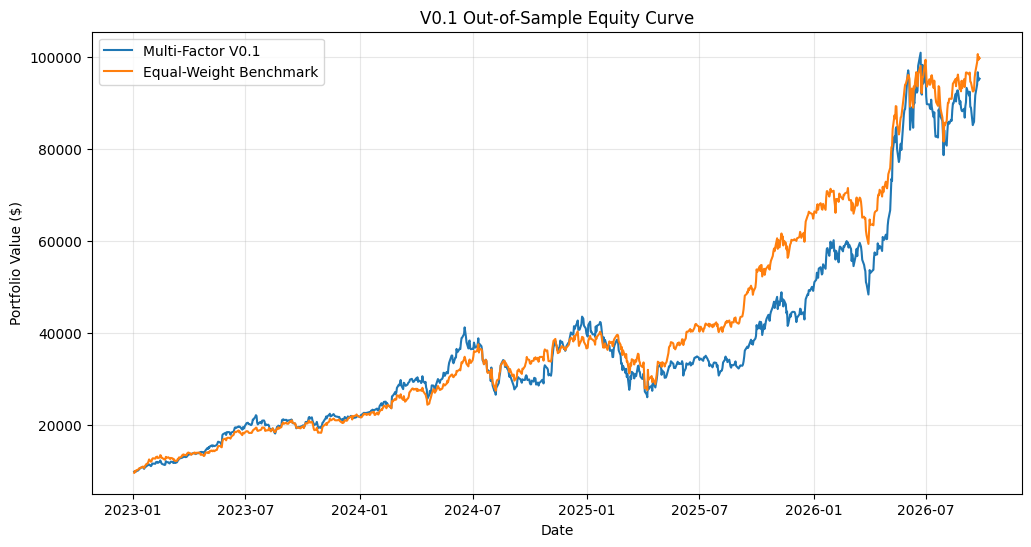

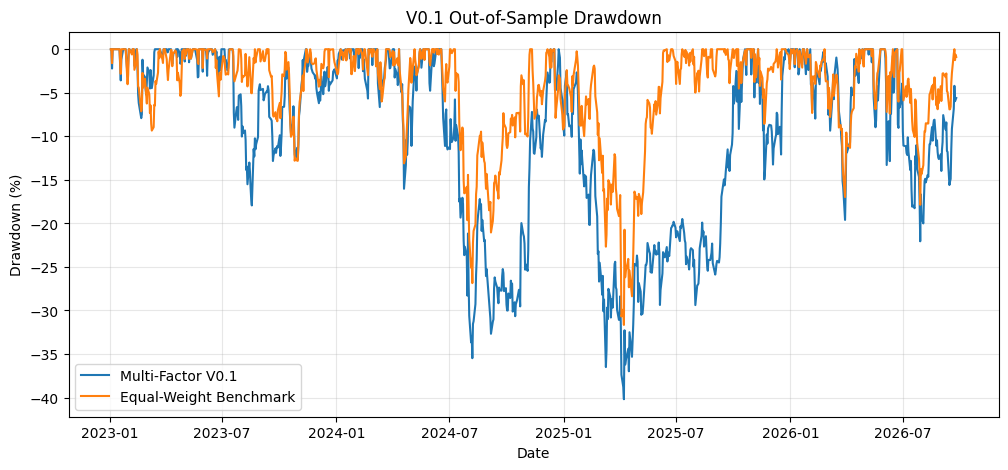

In [78]:
# Step 75: Performance Summary + Equity Curve + Drawdown

# ==========================================
# 1. Performance Summary
# ==========================================

performance_summary = pd.DataFrame({

    "Multi-Factor V0.1": [
        oos_strategy_equity.iloc[-1],
        oos_cagr * 100,
        oos_vol * 100,
        oos_sharpe,
        oos_mdd * 100
    ],

    "Equal-Weight Benchmark": [
        oos_benchmark_equity.iloc[-1],
        benchmark_oos_cagr * 100,
        benchmark_oos_vol * 100,
        benchmark_oos_sharpe,
        benchmark_oos_mdd * 100
    ]

}, index=[
    "Final Value ($)",
    "CAGR (%)",
    "Annualized Volatility (%)",
    "Sharpe Ratio",
    "Maximum Drawdown (%)"
])

print("=== Quant System V0.1 Performance Summary ===")
display(performance_summary.round(2))


# ==========================================
# 2. Equity Curve
# ==========================================

plt.figure(figsize=(12, 6))

plt.plot(
    oos_strategy_equity.index,
    oos_strategy_equity,
    label="Multi-Factor V0.1"
)

plt.plot(
    oos_benchmark_equity.index,
    oos_benchmark_equity,
    label="Equal-Weight Benchmark"
)

plt.title("V0.1 Out-of-Sample Equity Curve")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ==========================================
# 3. Drawdown Curve
# ==========================================

plt.figure(figsize=(12, 5))

plt.plot(
    oos_drawdown.index,
    oos_drawdown * 100,
    label="Multi-Factor V0.1"
)

plt.plot(
    benchmark_oos_drawdown.index,
    benchmark_oos_drawdown * 100,
    label="Equal-Weight Benchmark"
)

plt.title("V0.1 Out-of-Sample Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [79]:
# Step 76: Final Factor Registry for Quant System V0.1

factor_registry_v01 = pd.DataFrame({

    "Factor": [
        "Momentum120",
        "Earnings Growth",
        "Volatility20",
        "Volume20",
        "Momentum × Volume"
    ],

    "Type": [
        "Alpha",
        "Alpha",
        "Risk",
        "Alpha",
        "Interaction"
    ],

    "V0.1 Status": [
        "Selected",
        "Selected / Experimental",
        "Risk Tool Only",
        "Rejected",
        "Rejected"
    ],

    "Role": [
        "70% of Multi-Factor Score",
        "30% of Multi-Factor Score",
        "Tested for position sizing",
        "None",
        "None"
    ],

    "Conclusion": [
        "Positive momentum evidence in Train and Test",
        "Mixed evidence; stronger IC in Test",
        "Inverse-volatility sizing reduced risk slightly but lowered Sharpe",
        "IC near zero",
        "Failed out-of-sample validation"
    ]

})

print("=== Quant System V0.1 Factor Registry ===")

display(factor_registry_v01)

=== Quant System V0.1 Factor Registry ===


,Factor,Type,V0.1 Status,Role,Conclusion
0,Momentum120,Alpha,Selected,70% of Multi-Factor Score,Positive momentum evidence in Train and Test
1,Earnings Growth,Alpha,Selected / Experimental,30% of Multi-Factor Score,Mixed evidence; stronger IC in Test
2,Volatility20,Risk,Risk Tool Only,Tested for position sizing,Inverse-volatility sizing reduced risk slightl...
3,Volume20,Alpha,Rejected,None,IC near zero
4,Momentum × Volume,Interaction,Rejected,None,Failed out-of-sample validation
